<a href="https://colab.research.google.com/github/eliz121/indicadores_economicos/blob/main/KDD_BCE_Sistema_Financiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Objetivo 2 Sistema Financiero**

**Objetivo:** Evaluar el sistema financiero público y privado a través de indicadores monetarios y financieros para predecir tendencias y anomalías que afecten su estabilidad.

**Versión:** 3.0

# 0. Configuración del entorno

## 0.1 Reproducibilidad

In [ ]:
import os, random
import numpy as np

SEED = 42

def set_global_seed(seed: int = SEED) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # TensorFlow (si está disponible)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
        # Determinismo (puede reducir rendimiento, pero mejora reproducibilidad)
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
    except Exception:
        pass

set_global_seed(SEED)

## 0.2 Split y antileakage

In [ ]:
def time_series_split(X, y, test_size: float = 0.30):
    """Split cronológico (sin shuffle). Asume que X,y ya están ordenados por tiempo."""
    n = len(X)
    split = int(round(n * (1 - test_size)))
    X_train, X_test = X.iloc[:split].copy(), X.iloc[split:].copy()
    y_train, y_test = y.iloc[:split].copy(), y.iloc[split:].copy()
    return X_train, X_test, y_train, y_test

## 0.3 Métricas

In [ ]:
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

## 0.4 Robustez estadística

In [ ]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_boot: int = 2000, alpha: float = 0.05):
    """IC bootstrap (percentil) para una métrica. Robustez estadística."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    stats = []
    rng = np.random.default_rng(SEED)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        stats.append(metric_fn(y_true[idx], y_pred[idx]))
    lo = float(np.quantile(stats, alpha/2))
    hi = float(np.quantile(stats, 1-alpha/2))
    return lo, hi

## 0.5 Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.layers import Input, LayerNormalization, Dropout, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras import layers, models
from statsmodels.tsa.stattools import adfuller, kpss

# 1. Selección de datos

In [ ]:
df = pd.read_csv('AM2.csv', encoding='latin-1', sep=';')

## 1.5 EDA

Se utiliza para preparar los datos exclusivamente para el análisis exploratorio, asegurando que la información sea coherente y fácil de interpretar sin modificar el conjunto original que luego se usará para el modelado. Primero se crea una copia del DataFrame y se limpian los nombres de las columnas para evitar inconsistencias causadas por espacios o caracteres invisibles. Después, se identifica y convierte la columna que representa el tiempo a un formato de fecha, lo que permite ordenar los datos cronológicamente y trabajar correctamente con series de tiempo. A continuación, las variables se transforman a valores numéricos corrigiendo formatos habituales en datos económicos oficiales, como separadores de miles y decimales, para que los cálculos estadísticos sean válidos. Finalmente, se aplican rellenos suaves de valores faltantes solo con fines exploratorios y se generan estadísticas descriptivas de las variables de interés. En conjunto, este procedimiento garantiza que el análisis exploratorio se base en datos limpios, consistentes y ordenados temporalmente, sin introducir errores ni afectar las etapas posteriores de modelado.


In [ ]:
import numpy as np
import pandas as pd

# =========================
# Copia para EDA (aplicado a tu df actual)
# =========================
df_eda = df.copy()
df_eda.columns = [c.strip().replace('\xa0',' ').replace('  ',' ') for c in df_eda.columns]

# -------------------------
# Detección de columna de fecha
# -------------------------
date_col = None
for cand in ['fecha','Fecha','Período','Periodo','PERIODO','Año','Anio','year']:
    if cand in df_eda.columns:
        date_col = cand
        break
if date_col is None:
    # si no hay columna obvia, asume la primera
    date_col = df_eda.columns[0]

# -------------------------
# Conversión de fecha
# -------------------------
if date_col in ['Año','Anio','year']:
    df_eda['fecha'] = pd.to_datetime(df_eda[date_col].astype('Int64').astype(str) + '-01-01', errors='coerce')
else:
    df_eda['fecha'] = pd.to_datetime(
        df_eda[date_col].astype(str).str.replace('/', '-'),
        errors='coerce'
    )

df_eda = df_eda.dropna(subset=['fecha']).set_index('fecha').sort_index()

# -------------------------
# Conversión numérica (todas las columnas excepto fecha)
# -------------------------
for c in df_eda.columns:
    df_eda[c] = (df_eda[c].astype(str)
                 .str.replace('\u202f', '', regex=False)  # espacio fino (a veces aparece)
                 .str.replace(' ', '', regex=False)       # quita espacios
                 .str.replace('.','', regex=False)        # miles con punto
                 .str.replace(',','.', regex=False))      # decimal con coma
    df_eda[c] = pd.to_numeric(df_eda[c], errors='coerce')

# Rellenos suaves para EDA
df_eda = df_eda.ffill().bfill()

# -------------------------
# Si quieres SOLO tus num_cols (y existen), úsalo así:
# -------------------------
num_cols = [
    "Especies Monetarias en Circulación",
    "Moneda Fraccionaria",
    "Dinero Electrónico",
    "Depósitos a la vista",
    "Oferta Monetaria M1",
    "Cuasidinero",
    "LIQUIDEZ TOTAL M2",
    "Reservas Bancarias",
    "Caja BCE",
    "Caja OSD",
    "BASE MONETARIA BM",
    "Multiplicador  M1/BM",
    "Multiplicador M2/BM"
]
num_cols = [c.strip().replace('\xa0',' ').replace('  ',' ') for c in num_cols]
existing_num_cols = [c for c in num_cols if c in df_eda.columns]

### 1.5.1 Estadísticas descriptivas

In [ ]:
# Describe (todo o solo num_cols)
display(df_eda[existing_num_cols].describe().T if len(existing_num_cols) else df_eda.describe().T)

,count,mean,std,min,25%,50%,75%,max
Especies Monetarias en Circulación,302.0,8557.907285,6701.286997,530.4,2643.600,5440.55,15341.700,20302.2
Moneda Fraccionaria,302.0,70.731126,21.626114,0.0,62.425,80.40,85.200,93.4
Dinero Electrónico,302.0,0.544371,2.024374,0.0,0.000,0.00,0.000,11.3
Depósitos a la vista,302.0,6212.495033,3409.803585,533.8,2845.525,7119.50,9030.100,11732.1
Oferta Monetaria M1,302.0,14841.671854,9952.569860,1070.0,5503.075,12524.65,24539.575,31461.8
Cuasidinero,302.0,18687.552649,15038.962009,2199.9,5437.425,15848.60,27627.425,58490.8
LIQUIDEZ TOTAL M2,302.0,33529.220199,24781.634366,3278.4,10961.250,28331.50,52082.375,89845.3
Reservas Bancarias,302.0,2763.146689,2425.873815,124.6,418.350,2019.05,4756.175,8620.4
Caja BCE,302.0,408.006623,268.802555,18.9,154.850,429.75,570.350,1834.1
Caja OSD,302.0,887.124172,601.029470,85.5,298.000,808.60,1535.575,1904.7


**1.5.1.1 Interpretación**

En primer lugar, variables como Especies Monetarias en Circulación, Depósitos a la vista, Oferta Monetaria M1, Cuasidinero, Base Monetaria (BM) y Liquidez Total M2 presentan valores medios elevados y desviaciones estándar también altas, lo que indica un crecimiento significativo en el tiempo acompañado de una alta volatilidad. Esto es coherente con la evolución estructural del sistema monetario, donde los agregados tienden a incrementarse por efectos de expansión económica, inflación y cambios en la política monetaria. La diferencia entre la mediana (50 %) y la media en estas variables sugiere distribuciones asimétricas, asociadas a tendencias crecientes y posibles cambios de régimen a lo largo del período.

En contraste, variables como Moneda Fraccionaria, Caja BCE y Caja OSD muestran magnitudes promedio menores y una variabilidad más contenida, reflejando componentes operativos del sistema monetario que, aunque fluctúan, lo hacen dentro de rangos relativamente más estables. En el caso del Dinero Electrónico, se observa una media cercana a cero, una mediana nula y un valor máximo reducido, lo que indica que su presencia fue limitada durante gran parte del período y concentrada solo en ciertos años, generando una distribución altamente asimétrica.

Por su parte, los multiplicadores monetarios M1/BM y M2/BM presentan medias relativamente estables y desviaciones estándar bajas en comparación con los agregados monetarios en niveles. Esto sugiere que, aunque la base monetaria y los agregados crecieron en términos absolutos, la relación entre ellos se mantuvo dentro de rangos controlados, reflejando un comportamiento más estable del mecanismo de transmisión monetaria.

En conjunto, estas estadísticas descriptivas confirman que el dataset presenta heterogeneidad en escalas, alta dispersión en variables de nivel y estabilidad relativa en variables de razón, lo cual justifica la aplicación posterior de técnicas de normalización, análisis multivariado y modelos de series de tiempo para capturar adecuadamente la dinámica del sistema monetario.

### 1.5.2 Series temporales

Este gráfico se realiza para visualizar y comparar la evolución temporal de la Liquidez Total (M2) y la Base Monetaria (BM) a lo largo del período de estudio. Su propósito principal es identificar tendencias, ciclos y cambios estructurales en ambos agregados monetarios, así como analizar si existe un comportamiento conjunto o divergente entre ellos en el tiempo.

La representación gráfica permite observar de forma intuitiva cómo la liquidez total se expande en relación con la base monetaria, lo cual es clave para entender el funcionamiento del sistema monetario y el proceso de creación de dinero. Además, facilita la detección de períodos de crecimiento acelerado, estabilidad o contracción, que pueden estar asociados a decisiones de política monetaria, choques macroeconómicos o cambios en la estructura financiera. En el contexto del análisis exploratorio, este tipo de visualización sirve como una verificación preliminar de coherencia económica de los datos y como apoyo para justificar análisis posteriores, como el estudio de los multiplicadores monetarios o el uso de modelos de series de tiempo.

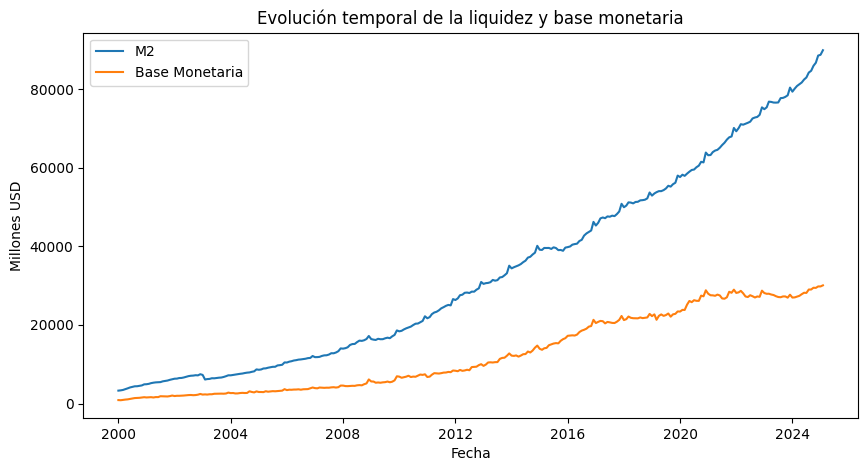

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import unicodedata # Needed for norm_text

# Now plot
plt.figure(figsize=(10,5))
plt.plot(df["fecha"], df["LIQUIDEZ TOTAL M2"], label="M2")
plt.plot(df["fecha"], df["BASE MONETARIA BM"], label="Base Monetaria")
plt.legend()
plt.title("Evolución temporal de la liquidez y base monetaria")
plt.xlabel("Fecha")
plt.ylabel("Millones USD")
plt.show()


**1.5.2.1 Interpretación**

Se observa que ambas series presentan una tendencia creciente de largo plazo, lo cual es coherente con el crecimiento nominal de la economía, la expansión del sistema financiero y los efectos acumulados de la política monetaria.

La Liquidez Total (M2) crece de forma más acelerada y mantiene niveles muy superiores a la Base Monetaria, reflejando el proceso de creación secundaria de dinero a través del sistema bancario. Este comportamiento indica que los depósitos, el cuasidinero y otros componentes financieros amplifican la base monetaria inicial, generando una expansión mayor del agregado monetario amplio. La separación creciente entre ambas curvas sugiere un fortalecimiento del multiplicador monetario en ciertos períodos.

Por su parte, la Base Monetaria muestra un crecimiento más gradual, con etapas de aceleración y relativa estabilidad, lo que suele estar asociado a decisiones de política monetaria, necesidades de liquidez del sistema financiero y respuestas a choques macroeconómicos. En algunos tramos se aprecia una moderación del crecimiento de la base frente a una expansión sostenida de M2, lo que refuerza la idea de que el crédito y los depósitos juegan un rol central en la dinámica monetaria.

En conjunto, el gráfico permite concluir que existe una relación positiva y de largo plazo entre la Base Monetaria y la Liquidez Total, pero con magnitudes y ritmos de crecimiento distintos. Esta evidencia visual justifica análisis posteriores sobre multiplicadores monetarios, estabilidad del sistema financiero y modelado de series de tiempo para capturar la interacción dinámica entre ambos agregados.

### 1.5.3 Variación mensual e interanual

Es esencial para la evaluación de la estabilidad financiera, ya que permite identificar y cuantificar cambios significativos en agregados monetarios como la liquidez (M2). La variación mensual ofrece una perspectiva de corto plazo, detectando movimientos recientes que pueden indicar presiones inflacionarias o deflacionarias, o cambios rápidos en el comportamiento de los agentes económicos. Por otro lado, la variación interanual es fundamental para aislar la tendencia subyacente al eliminar el ruido de la estacionalidad inherente a muchos indicadores económicos, facilitando así la comprensión del crecimiento estructural y la formulación de políticas monetarias a mediano y largo plazo, además de servir como insumo clave para modelos predictivos y detección de anomalías al proporcionar una medida robusta de la dinámica de los agregados monetarios.

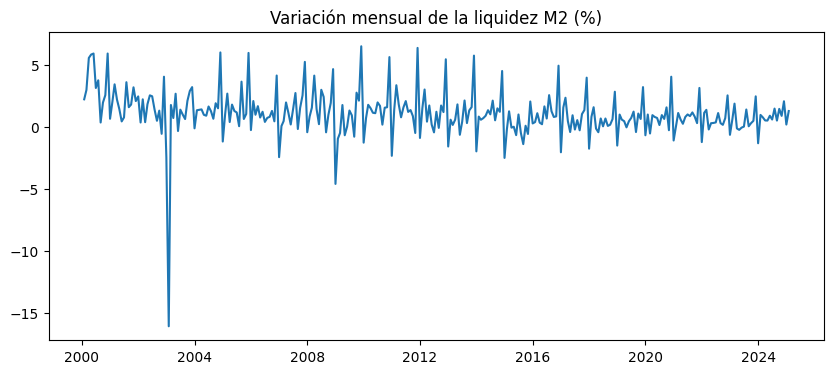

In [ ]:
df["M2_mensual"] = df["LIQUIDEZ TOTAL M2"].pct_change() * 100
df["M2_anual"] = df["LIQUIDEZ TOTAL M2"].pct_change(12) * 100

plt.figure(figsize=(10,4))
plt.plot(df["fecha"], df["M2_mensual"])
plt.title("Variación mensual de la liquidez M2 (%)")
plt.show()

**1.5.3.1 Interpretación**

A diferencia del nivel de M2, esta representación pone en evidencia la volatilidad mensual, mostrando cómo la liquidez se expande o se contrae de un mes a otro.

Se observa que la mayoría de las variaciones se concentran alrededor de valores cercanos a cero y ligeramente positivos, lo que indica que, en promedio, la liquidez tiende a crecer de forma moderada y sostenida. Sin embargo, también se identifican picos positivos y negativos, que reflejan episodios de expansión o contracción más pronunciados, asociados a choques económicos, ajustes de política monetaria o cambios en el comportamiento del sistema financiero.

Destaca un evento extremo de variación negativa a inicios de la serie, que sugiere una contracción abrupta de la liquidez en un período específico. Este tipo de observaciones es relevante desde el punto de vista analítico, ya que puede corresponder a cambios metodológicos, procesos de dolarización, crisis financieras o reestructuraciones del sistema monetario, y justifica la necesidad de analizar outliers y aplicar técnicas robustas en el modelado.

En conjunto, este gráfico permite caracterizar la estacionariedad aproximada de la tasa de crecimiento de M2, identificar episodios de alta volatilidad y fundamentar la elección de transformaciones como tasas de variación o diferenciación en los modelos de series de tiempo, en lugar de trabajar directamente con los niveles del agregado monetario.

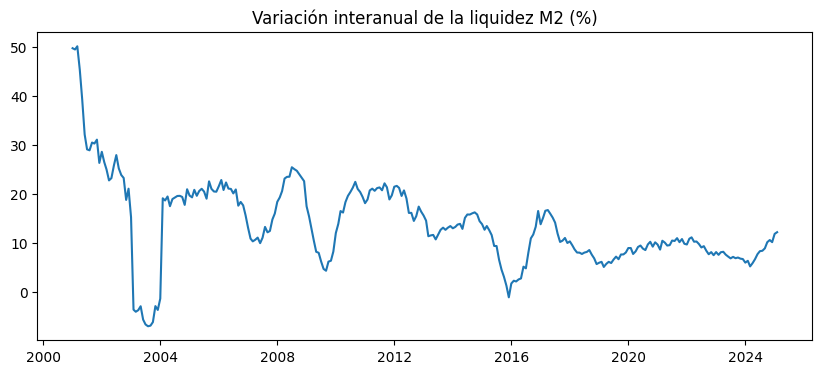

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["fecha"], df["M2_anual"])
plt.title("Variación interanual de la liquidez M2 (%)")
plt.show()

**1.5.3.2 Interpretación**

Este indicador permite analizar la dinámica de mediano plazo de la liquidez, suavizando la volatilidad mensual y facilitando la identificación de fases de expansión y desaceleración monetaria.

En los primeros años del período se observa una alta tasa de crecimiento interanual, seguida de una caída abrupta que incluso alcanza valores negativos, lo que evidencia un proceso de fuerte ajuste monetario. Este comportamiento suele asociarse a cambios estructurales en el sistema económico y financiero, como crisis, reformas monetarias o modificaciones en la metodología de registro de los agregados. Posteriormente, la serie muestra ciclos de recuperación y desaceleración, con tasas interanuales que oscilan dentro de rangos más moderados.

A lo largo del tiempo, la variación interanual tiende a estabilizarse en valores positivos, generalmente entre un solo dígito y niveles cercanos al 20 %, lo que sugiere una expansión más controlada de la liquidez en comparación con los primeros años. Los picos y valles observados reflejan la respuesta del sistema monetario a choques macroeconómicos, episodios de mayor crecimiento económico o periodos de restricción financiera.

En conjunto, este gráfico es clave para evaluar la estabilidad del crecimiento monetario, identificar posibles cambios de régimen y respaldar la elección de modelos que trabajen con tasas interanuales o incorporen componentes cíclicos, ya que esta transformación reduce la tendencia y resalta la dinámica económica subyacente de la liquidez.

### 1.5.4 Distribución y densidad

La visualización de la distribución y densidad de una variable, como la variación mensual de M2, es crucial para entender la naturaleza intrínseca de los datos. Permite identificar si los valores se concentran alrededor de una media, si existen asimetrías (sesgos) que puedan indicar comportamientos anómalos o estructurales, o si la presencia de múltiples picos (multimodalidad) sugiere la existencia de subgrupos dentro de la población. Este análisis es fundamental para validar suposiciones previas sobre la normalidad de los datos, guiar la selección de transformaciones necesarias para el modelado (por ejemplo, para lograr distribuciones más simétricas), y como una primera etapa robusta para la detección de valores atípicos que puedan sesgar cualquier análisis o predicción posterior, asegurando así una base sólida para inferencias estadísticas y modelos predictivos.

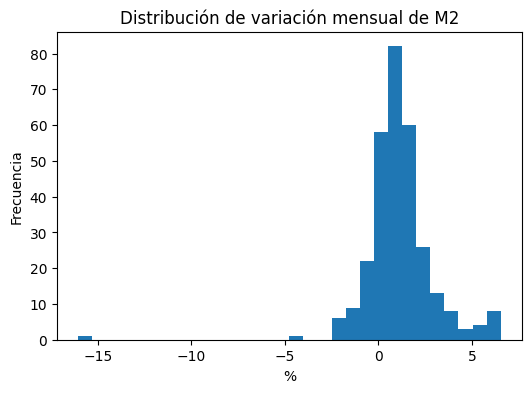

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["M2_mensual"].dropna(), bins=30)
plt.title("Distribución de variación mensual de M2")
plt.xlabel("%")
plt.ylabel("Frecuencia")
plt.show()

**1.5.4.1 Interpretación**

La mayor parte de las observaciones se agrupa alrededor de valores cercanos a cero y ligeramente positivos, lo que indica que, en la mayoría de los meses, M2 crece de forma moderada y estable.

La forma de la distribución revela una asimetría, con una cola más extendida hacia los valores negativos, lo que refleja la presencia de episodios poco frecuentes pero intensos de contracción monetaria. Estos eventos extremos, visibles como barras aisladas en los extremos del histograma, suelen estar asociados a choques económicos o ajustes extraordinarios en el sistema monetario. Por otro lado, la cola positiva muestra que también existen meses con expansiones superiores al promedio, aunque con menor frecuencia.

Este análisis es relevante porque permite identificar la no normalidad de la serie, lo que tiene implicaciones metodológicas para el modelado estadístico y econométrico. En particular, la presencia de asimetría y valores atípicos justifica el uso de técnicas robustas, transformaciones adecuadas o métricas menos sensibles a extremos en etapas posteriores del análisis.

### 1.5.5 Correlación

Ayuda a cuantificar y visualizar la fuerza y dirección de la relación lineal entre pares de variables numéricas. Esto es crucial para comprender cómo los diferentes agregados monetarios (M1, M2, Base Monetaria, Reservas Bancarias, Multiplicador M2/BM) se mueven conjuntamente, permitiendo identificar variables redundantes, posibles relaciones causales (aunque la correlación no implica causalidad), y seleccionar características relevantes para modelos predictivos, ya que las variables altamente correlacionadas pueden influir recíprocamente o compartir una dependencia con un factor común, lo cual es vital para la construcción de un sistema financiero robusto y predictivo.

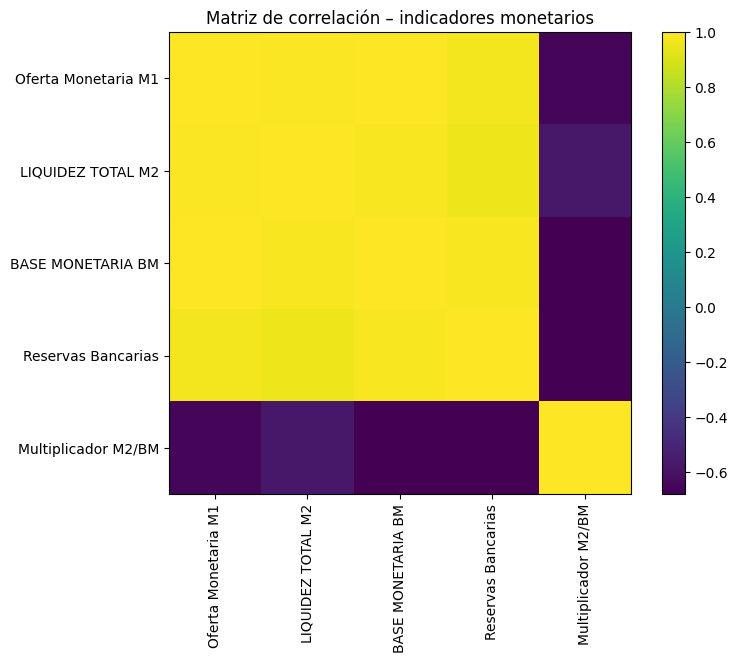

In [ ]:
corr_vars = [
    "Oferta Monetaria M1",
    "LIQUIDEZ TOTAL M2",
    "BASE MONETARIA BM",
    "Reservas Bancarias",
    "Multiplicador M2/BM"
]

corr = df[corr_vars].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Matriz de correlación – indicadores monetarios")
plt.show()

**1.5.5.1 Interpretación**

Se observa una correlación positiva muy alta entre la Oferta Monetaria M1, la Liquidez Total M2, la Base Monetaria (BM) y las Reservas Bancarias, con coeficientes cercanos a 1. Esto indica que estos agregados tienden a crecer o disminuir simultáneamente en el tiempo, lo cual es consistente con la teoría monetaria: la expansión de la base monetaria y de las reservas bancarias se transmite hacia agregados más amplios como M1 y M2 a través del sistema financiero.

En contraste, el Multiplicador M2/BM presenta una correlación negativa con el resto de variables. Esto sugiere que, en períodos en los que la base monetaria y los agregados monetarios aumentan con mayor intensidad, el multiplicador tiende a reducirse, lo que puede interpretarse como una mayor expansión de la base en relación con la liquidez total o una menor eficiencia del mecanismo de creación secundaria de dinero. Este comportamiento es habitual en contextos de políticas monetarias expansivas, donde el crecimiento de la base no siempre se traduce proporcionalmente en un aumento del crédito o de los depósitos.

En conjunto, la matriz evidencia una alta colinealidad entre los agregados monetarios en niveles, lo que justifica el uso de técnicas como análisis de componentes principales, selección de variables o transformaciones (tasas de crecimiento, ratios) antes del modelado. Además, resalta el papel diferenciado del multiplicador monetario como indicador estructural del funcionamiento del sistema financiero, más que como una variable que evoluciona en paralelo con los agregados en niveles.

### 1.5.6 Estacionariedad

Su importancia radica en que la mayoría de los modelos estadísticos y econométricos asumen que las propiedades estadísticas de una serie (su media, varianza y estructura de autocorrelación) son constantes a lo largo del tiempo. Sin esta condición, las relaciones observadas y las predicciones generadas por los modelos pueden ser espurias o poco fiables. Los tests de raíz unitaria como el ADF y el KPSS se utilizan precisamente para verificar esta condición: si una serie no es estacionaria, es decir, presenta una tendencia o una varianza cambiante, es necesario aplicar transformaciones (como la diferenciación) para alcanzar la estacionariedad y así poder emplear modelos robustos que permitan realizar inferencias válidas y pronósticos precisos sobre su comportamiento futuro.

In [ ]:
def adf_test(series, name):
    res = adfuller(series.dropna())
    print(f"ADF {name}: p-value = {res[1]:.4f}")

def kpss_test(series, name):
    res = kpss(series.dropna(), regression='c')
    print(f"KPSS {name}: p-value = {res[1]:.4f}")

adf_test(df["LIQUIDEZ TOTAL M2"], "M2")
kpss_test(df["LIQUIDEZ TOTAL M2"], "M2")

ADF M2: p-value = 1.0000
KPSS M2: p-value = 0.0100


/tmp/ipython-input-118539707.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(series.dropna(), regression='c')


**1.5.6.1 Interpretación**

Los resultados de las pruebas ADF y KPSS aplicadas a la serie M2 indican claramente que la serie no es estacionaria en niveles, lo cual es consistente con su comportamiento económico y con la tendencia creciente observada en los gráficos.

En el caso de la prueba ADF (Augmented Dickey–Fuller), el p-value es igual a 1.0000, muy por encima de cualquier nivel de significancia usual (1 %, 5 % o 10 %). Esto implica que no se rechaza la hipótesis nula de raíz unitaria, es decir, la serie M2 presenta una tendencia estocástica y no es estacionaria. En términos prácticos, el nivel de la liquidez total evoluciona con una trayectoria persistente en el tiempo y no fluctúa alrededor de una media constante.

Por su parte, la prueba KPSS arroja un p-value de 0.0100, acompañado de una advertencia que indica que el estadístico calculado se encuentra fuera del rango de la tabla de valores críticos, por lo que el p-value real es incluso menor al reportado. En este test, la hipótesis nula es que la serie sí es estacionaria, por lo que un p-value tan bajo conduce a rechazar la estacionariedad. Esto refuerza la conclusión de que M2 en niveles presenta tendencia y no cumple el supuesto de estacionariedad.

En conjunto, ambas pruebas son consistentes entre sí: ADF no rechaza raíz unitaria y KPSS rechaza estacionariedad. Este resultado confirma que la serie M2 debe ser transformada antes de ser utilizada en modelos de series de tiempo, por ejemplo mediante diferenciación, tasas de crecimiento o variaciones interanuales, con el fin de eliminar la tendencia y trabajar con una serie aproximadamente estacionaria, condición necesaria para muchos modelos econométricos y de aprendizaje automático.

### 1.5.7 Anomalías (IQR)

Técnica robusta y no paramétrica fundamental para identificar valores atípicos que se desvían significativamente del patrón general de los datos. Esta metodología es crucial porque permite establecer umbrales dinámicos basados en la distribución intrínseca de la variable (Q1 - 1.5 * IQR y Q3 + 1.5 * IQR), minimizando la influencia de los propios valores extremos en la definición de estos límites. Su propósito es filtrar y señalar aquellos puntos de datos que podrían representar errores de medición, eventos excepcionales, o cambios estructurales que merecen una investigación profunda, sirviendo como un paso esencial en la limpieza de datos, la validación de la calidad de la información y la anticipación de posibles desviaciones en el comportamiento de indicadores financieros como M2.

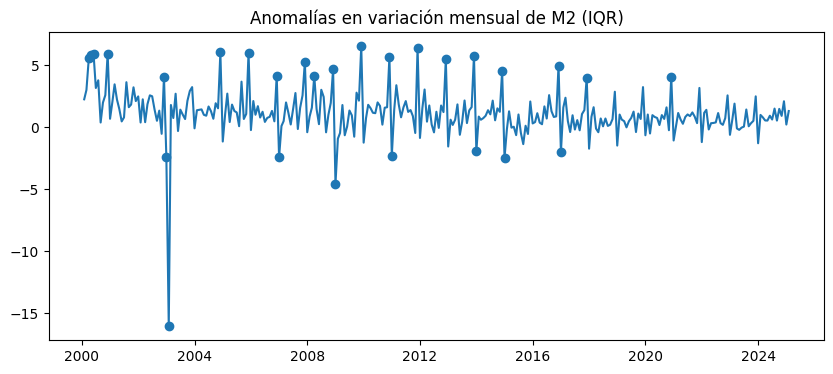

In [ ]:
q1 = df["M2_mensual"].quantile(0.25)
q3 = df["M2_mensual"].quantile(0.75)
iqr = q3 - q1

df["outlier_M2"] = (
    (df["M2_mensual"] < q1 - 1.5 * iqr) |
    (df["M2_mensual"] > q3 + 1.5 * iqr)
)

plt.figure(figsize=(10,4))
plt.plot(df["fecha"], df["M2_mensual"])
plt.scatter(df.loc[df["outlier_M2"], "fecha"],
            df.loc[df["outlier_M2"], "M2_mensual"])
plt.title("Anomalías en variación mensual de M2 (IQR)")
plt.show()

**1.5.7.1 Interpretación**

La serie principal representa la variación mensual de M2, mientras que los puntos destacados señalan episodios atípicos, tanto de expansiones como de contracciones extraordinarias de la liquidez. Se observa un evento extremo de fuerte contracción a inicios del período, claramente separado del resto de las observaciones, así como varios picos positivos y negativos distribuidos a lo largo del tiempo. Estos episodios reflejan meses en los que la dinámica monetaria se desvió de su patrón habitual.

La identificación de estas anomalías es relevante porque indica la presencia de choques monetarios o eventos excepcionales, que pueden estar asociados a crisis económicas, cambios regulatorios, ajustes de política monetaria o modificaciones metodológicas en la medición de los agregados. Desde el punto de vista del análisis y el modelado, este resultado justifica el uso de técnicas robustas (por ejemplo, métricas menos sensibles a outliers o transformaciones adicionales) y la evaluación cuidadosa de si estos valores deben conservarse por su significado económico o tratarse de forma especial para evitar que distorsionen los modelos predictivos.

En conjunto, el gráfico confirma que, aunque la variación mensual de M2 suele ser relativamente estable, existen episodios extremos poco frecuentes que concentran gran parte de la volatilidad y que deben ser considerados explícitamente en el análisis econométrico y de aprendizaje automático.

### 1.5.8 Boxplots de agregados monetarios

Son cruciales para visualizar de manera concisa la distribución de una variable numérica clave. Su propósito es identificar rápidamente la mediana, los cuartiles (Q1 y Q3), el rango intercuartílico (IQR), y, muy importante, la presencia y magnitud de valores atípicos (outliers) en las variables financieras. Esto permite una comparación directa de la dispersión y la simetría entre diferentes agregados como M1, M2 y la Base Monetaria, facilitando la detección de anomalías o comportamientos inusuales en el sistema financiero que podrían no ser evidentes con otras estadísticas descriptivas y que son vitales para una evaluación robusta y la toma de decisiones.

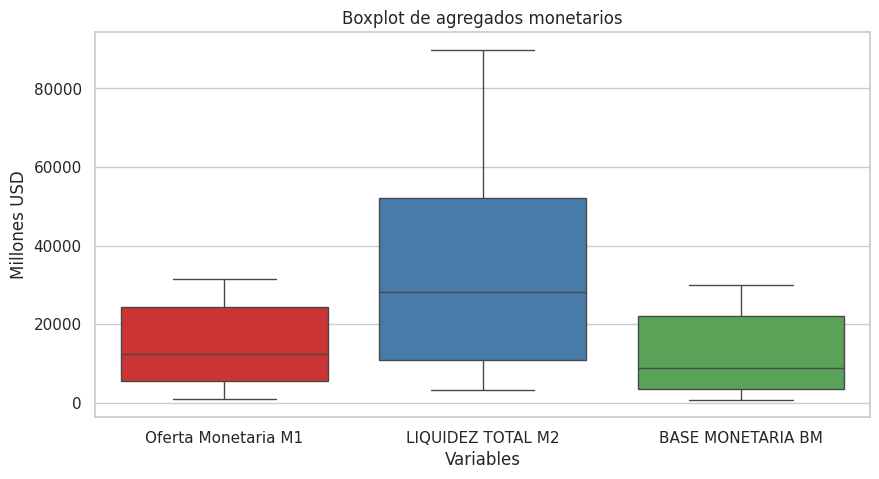

In [ ]:
vars_box = [
    "Oferta Monetaria M1",
    "LIQUIDEZ TOTAL M2",
    "BASE MONETARIA BM"
]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.boxplot(data=df[vars_box], palette="Set1")

plt.title("Boxplot de agregados monetarios")
plt.ylabel("Millones USD")
plt.xlabel("Variables")
plt.show()

**1.5.8.1 Interpretación**

Se observa que la Liquidez Total M2 presenta los valores más altos y la mayor dispersión, lo que indica una variabilidad considerable en el tiempo y confirma su carácter de agregado monetario amplio. La amplitud de la caja y la longitud de los bigotes reflejan que M2 experimentó fuertes cambios, coherentes con procesos de expansión monetaria y crecimiento del sistema financiero.

La Oferta Monetaria M1 muestra una dispersión intermedia, con una mediana inferior a la de M2 pero superior a la de la Base Monetaria. Esto sugiere que, aunque M1 crece y fluctúa de manera importante, lo hace dentro de un rango más acotado que la liquidez total, reflejando su composición más restringida.

Por su parte, la Base Monetaria presenta niveles más bajos y una distribución más concentrada, lo que indica una variabilidad relativamente menor en comparación con M1 y M2. Este comportamiento es consistente con su rol como instrumento directo de la política monetaria, cuyo crecimiento suele estar más controlado.

En conjunto, el boxplot evidencia diferencias claras en escala y volatilidad entre los agregados monetarios, así como posibles asimetrías asociadas a tendencias crecientes en el tiempo. Esta visualización respalda la necesidad de aplicar transformaciones o normalizaciones antes del modelado y refuerza la interpretación económica de la jerarquía entre los agregados monetarios.

# 2. Preprocesamiento

Busca limpiar, estructurar y estandarizar el conjunto de datos de entrada para asegurar su calidad y adecuación para los análisis posteriores. Su propósito principal es abordar problemas como valores faltantes, formatos inconsistentes (ej. nombres de columnas, fechas, separadores decimales), tipos de datos incorrectos y errores de entrada que, de no corregirse, podrían sesgar los resultados de cualquier modelo o análisis. Al estandarizar los nombres de las columnas, unificar formatos de texto y convertir datos a tipos numéricos correctos, el preprocesamiento garantiza que las operaciones subsiguientes (como cálculos estadísticos o la alimentación a modelos de Machine Learning) se realicen sobre información confiable y en un formato consistente, sentando las bases para inferencias válidas y un rendimiento robusto del modelo.

In [ ]:
# --- Preprocessing steps to ensure 'fecha' and numeric columns are ready ---

# 0) Ensure column names are clean (remove leading/trailing spaces, replace non-breaking spaces)
# This step is critical because column names might have invisible characters or inconsistent spacing.
df.columns = [c.strip().replace('\xa0',' ').replace('  ',' ') for c in df.columns]

# 1) Normalize text of Mes and map to number
def norm_text(s):
    """minúsculas + sin tildes + sin espacios extremos"""
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    s = "".join(ch for ch in unicodedata.normalize("NFD", s) if unicodedata.category(ch) != "Mn")
    return s

df["Mes_norm"] = df["Mes"].apply(norm_text)

mes_map = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "setiembre": 9, # Added 'setiembre' as it appears in typical Spanish datasets
    "octubre": 10, "noviembre": 11, "diciembre": 12
}

df["Mes_num"] = df["Mes_norm"].map(mes_map)

# 2) Create 'fecha' column
df["fecha"] = pd.to_datetime(
    dict(year=df["Año"].astype(int), month=df["Mes_num"].astype(int), day=1),
    errors="coerce"
)

# Drop rows where 'fecha' could not be created or is missing, and sort
df = df.dropna(subset=['fecha']).sort_values("fecha").reset_index(drop=True)

# 3) Robust conversion to numeric for plotting columns
def to_float(x):
    # converts "1.067,2" -> 1067.2  |  "501,1" -> 501.1
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.replace(" ", "")
    x = x.replace(".", "")      # thousands separator
    x = x.replace(",", ".")     # decimal separator
    return pd.to_numeric(x, errors="coerce")

plot_cols_numeric = ["LIQUIDEZ TOTAL M2", "BASE MONETARIA BM"] # Use the names as they appear in the original plot call

for c in plot_cols_numeric:
    if c in df.columns: # Check if column exists after cleaning names
        df[c] = df[c].apply(to_float)

# --- End of preprocessing steps ---

# 3. Transformación

Creación de nuevas variables o la modificación de las existentes para resaltar patrones, ajustar la distribución de los datos o generar características que mejoren el poder predictivo de los modelos. Su objetivo es, por un lado, hacer que los datos sean más interpretables o adecuados para ciertos algoritmos (ej. lograr estacionariedad mediante diferenciación en series temporales) y, por otro, crear nuevas perspectivas analíticas (ej. calcular participaciones relativas o variaciones porcentuales como Delta_M2). Estas transformaciones permiten capturar la dinámica subyacente de las variables (como las variaciones de la liquidez M2), entender la estructura del sistema financiero a través de composiciones relativas, o preparar los datos para satisfacer los supuestos de modelos específicos, optimizando así la capacidad de predicción y la explicabilidad del comportamiento del sistema monetario.

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.isna, pd.to_numeric

# Re-defining to_float here to ensure it's available and applied correctly,
# as the previous definition and application might have been incomplete or in a separate cell
# not guaranteed to be executed in the right order for all required columns.
def to_float(x):
    # converts "1.067,2" -> 1067.2  |  "501,1" -> 501.1
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.replace(" ", "")
    x = x.replace(".", "")      # thousands separator
    x = x.replace(",", ".")     # decimal separator
    return pd.to_numeric(x, errors="coerce")


work = df.copy()

# Define the columns that need to be numeric for calculations in this cell
# These include 'LIQUIDEZ TOTAL M2' and all columns in 'comp_cols'.
columns_to_ensure_numeric = [
    "LIQUIDEZ TOTAL M2",
    "Oferta Monetaria M1",
    "Cuasidinero",
    "Reservas Bancarias",
    "Caja BCE",
    "Caja OSD"
]

# Apply the to_float conversion to all these columns to ensure they are numeric.
for col in columns_to_ensure_numeric:
    if col in work.columns: # Check if column exists before trying to convert
        work[col] = work[col].apply(to_float)

# 1) Target: variación de la liquidez (ΔM2)
work["Delta_M2"] = work["LIQUIDEZ TOTAL M2"].pct_change()

# 2) Variación anual (opcional)
work["Delta_M2_aa"] = work["LIQUIDEZ TOTAL M2"].pct_change(12)

# 3) Participaciones (estructura del sistema financiero)
comp_cols = [
    "Oferta Monetaria M1",
    "Cuasidinero",
    "Reservas Bancarias",
    "Caja BCE",
    "Caja OSD"
]

for c in comp_cols:
    # Now, work[c] and work["LIQUIDEZ TOTAL M2"] are guaranteed to be numeric,
    # so the division will be performed correctly.
    work[f"share_{c}"] = work[c] / work["LIQUIDEZ TOTAL M2"].replace(0, np.nan)

# 4) Limpieza final
work = work.replace([np.inf, -np.inf], np.nan).dropna()


# 4. Minería/Modelado

## 4.1 Clústering (K-Means)

K-Means es un algoritmo de clústering no supervisado que agrupa puntos de datos en 'k' clusters basándose en su similitud, buscando minimizar la varianza intra-clúster. Su uso en el notebook para las 'shares' (participaciones de componentes financieros) permite segmentar los períodos según la estructura de la liquidez, identificando regímenes o comportamientos distintos del sistema financiero.

### 4.1.1 Método del codo

Para determinar el número óptimo de clusters 'k', se emplean técnicas como el Método del Codo (que busca un punto de inflexión en la curva de inercia, donde añadir más clusters no mejora significativamente la explicación de la varianza)

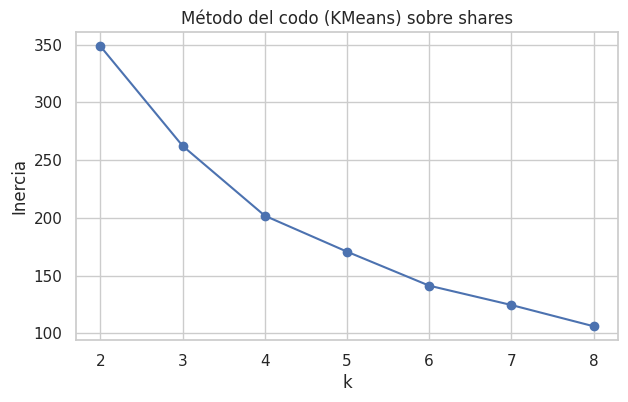

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

share_cols = [c for c in work.columns if c.startswith("share_")]
X = work[share_cols].copy()

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Codo
inertias = []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(Xs)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(list(K), inertias, marker="o")
plt.title("Método del codo (KMeans) sobre shares")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.show()

### 4.1.2 Coeficiente de la silueta

Evalúa la calidad de los clusters midiendo qué tan similares son los objetos dentro de su propio cluster en comparación con otros clusters, buscando valores cercanos a 1). Ambos métodos son fundamentales para validar la robustez y la interpretabilidad de la segmentación obtenida.

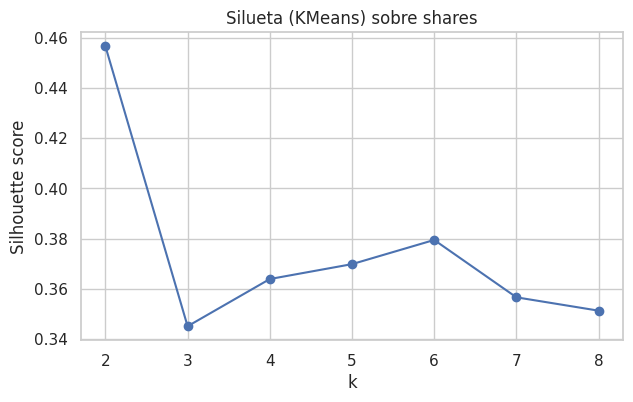

In [ ]:
sil = []
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(Xs)
    sil.append(silhouette_score(Xs, labels))

plt.figure(figsize=(7,4))
plt.plot(list(K), sil, marker="o")
plt.title("Silueta (KMeans) sobre shares")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show()

In [ ]:
# Modelo final
k_final = 2
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
work["cluster_comp"] = kmeans.fit_predict(Xs)
work["cluster_comp"].value_counts().sort_index()

,count
cluster_comp,
0,98
1,36


## 4.2 Detección de anomalías (Isolation Forest)

Algoritmo de detección de anomalías basado en árboles de decisión que aísla las observaciones anómalas al requerir menos 'divisiones' aleatorias para separarlas del resto de los datos. Opera bajo la premisa de que los puntos anómalos son pocos y distintos, y por lo tanto, más fáciles de aislar que los puntos normales. Su propósito es identificar patrones de comportamiento inusuales o eventos extremos en las variables financieras, como Delta_M2 u otros agregados, que podrían indicar disrupciones o cambios inesperados en el sistema. Al calcular un 'score de anomalía' para cada punto, este método permite señalar de forma eficiente aquellos períodos que se desvían significativamente del patrón establecido, lo cual es vital para la vigilancia y la gestión de riesgos financieros.

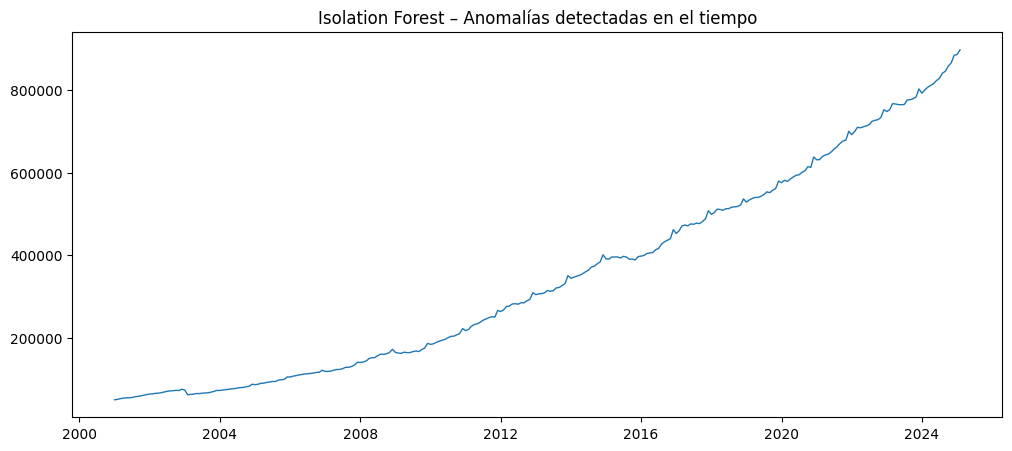

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# --- 0) Asegurar fecha ---
if "fecha" in work.columns:
    work["fecha"] = pd.to_datetime(work["fecha"])
    work = work.sort_values("fecha").set_index("fecha")
else:
    work.index = pd.to_datetime(work.index)
    work = work.sort_index()

# --- 1) Features para Isolation Forest (elige las que tengas) ---
feat_if = [
    "Delta_M2",                 # target transform (si la tienes)
    "Oferta Monetaria M1",
    "Cuasidinero",
    "Reservas Bancarias",
    "Caja BCE",
    "Caja OSD",
    "BASE MONETARIA BM"
]
feat_if = [c for c in feat_if if c in work.columns]

X = work[feat_if].replace([np.inf, -np.inf], np.nan).dropna()

# --- 2) Escalado (recomendado) ---
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# --- 3) Isolation Forest ---
iso = IsolationForest(
    n_estimators=300,
    contamination=0.10,   # ajusta: 0.05 a 0.15 típico
    random_state=42
)
pred = iso.fit_predict(Xs)          # -1 = anomalía, 1 = normal
score = iso.decision_function(Xs)   # más bajo = más anómalo

# Guardar resultados
work.loc[X.index, "anomaly_if"] = (pred == -1).astype(int)
work.loc[X.index, "score_if"] = score

# --- 4A) Gráfico: anomalías en el tiempo (línea/markers) ---
plt.figure(figsize=(12,5))
plt.title("Isolation Forest – Anomalías detectadas en el tiempo")
y_plot = "LIQUIDEZ TOTAL M2" if "LIQUIDEZ TOTAL M2" in work.columns else feat_if[0]
plt.plot(work.index, work[y_plot], linewidth=1)

Se observa una tendencia creciente de largo plazo, consistente con un proceso de expansión monetaria sostenida. Dentro de esta trayectoria, las anomalías detectadas no corresponden a valores aislados sin sentido, sino que se concentran en tramos donde la pendiente de la serie cambia de forma abrupta o donde se producen saltos pronunciados respecto al comportamiento esperado. Esto indica que el algoritmo está captando rupturas temporales o choques más que simples fluctuaciones menores.

Desde una interpretación económica, estas anomalías pueden asociarse a eventos extraordinarios que alteran la dinámica normal de la variable monetaria, como cambios en la política monetaria, episodios de estrés financiero, ajustes regulatorios o shocks macroeconómicos. El hecho de que las anomalías aparezcan en momentos específicos del tiempo y no de forma aleatoria refuerza la idea de que la serie presenta regímenes diferenciados.

Este resultado es relevante para el análisis predictivo, ya que confirma que la serie de ΔM2 está influenciada por episodios no lineales y no estacionarios. En consecuencia, la presencia de anomalías justifica el uso de modelos flexibles y no lineales, como CNN1D y otros enfoques de aprendizaje profundo, que son más capaces de adaptarse a cambios estructurales y patrones irregulares que los modelos puramente lineales o estadísticos.

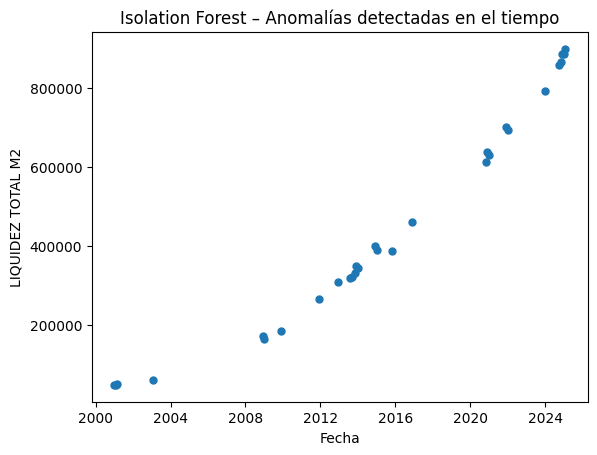

In [ ]:
anom_idx = work.index[work["anomaly_if"] == 1]
plt.scatter(anom_idx, work.loc[anom_idx, y_plot], s=25)
plt.title("Isolation Forest – Anomalías detectadas en el tiempo")
plt.ylabel(y_plot)
plt.xlabel("Fecha")
plt.show()

Las anomalías no aparecen distribuidas de manera uniforme, sino que se concentran en momentos específicos del período analizado, particularmente en tramos donde el nivel de M2 experimenta incrementos abruptos o cambios marcados en su trayectoria.

Se observa que, en los primeros años, las anomalías corresponden a valores relativamente bajos de M2, asociados a etapas tempranas del proceso de crecimiento monetario. Posteriormente, las observaciones atípicas se concentran en períodos intermedios y recientes, coincidiendo con saltos significativos en el nivel de liquidez, lo que sugiere episodios de expansión monetaria fuera del patrón histórico normal.

Desde una perspectiva económica, estas anomalías pueden interpretarse como choques exógenos o cambios de régimen, vinculados a decisiones de política monetaria, condiciones financieras excepcionales o eventos macroeconómicos relevantes. El hecho de que el algoritmo identifique anomalías principalmente en los extremos de la serie refuerza la idea de que la dinámica de M2 no es lineal ni homogénea a lo largo del tiempo.

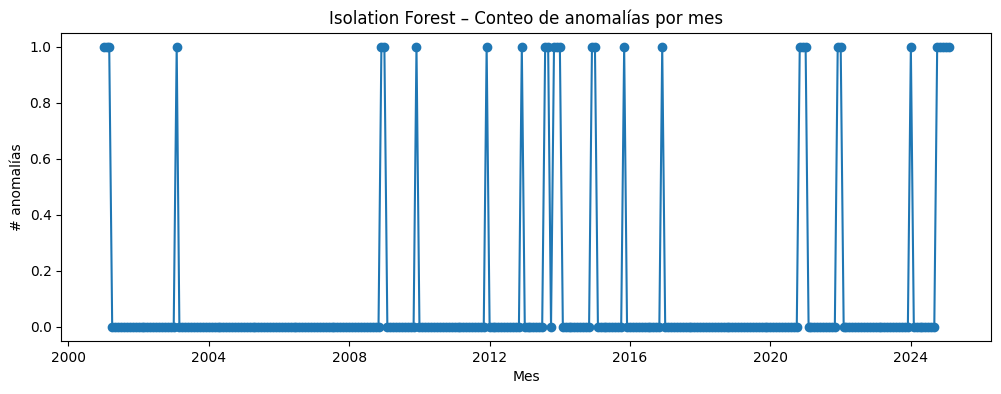

In [ ]:
# --- 4B) Conteo de anomalías por MES ---
anom_month = work["anomaly_if"].dropna().resample("MS").sum()
plt.figure(figsize=(12,4))
plt.plot(anom_month.index, anom_month.values, marker="o")
plt.title("Isolation Forest – Conteo de anomalías por mes")
plt.ylabel("# anomalías")
plt.xlabel("Mes")
plt.show()

Se observa que las anomalías se concentran en años específicos, especialmente en etapas donde la trayectoria de M2 experimenta cambios bruscos o aceleraciones inusuales. La ausencia de meses con múltiples anomalías simultáneas sugiere que estos eventos no corresponden a ruido sistemático, sino a choques discretos que alteran temporalmente el comportamiento normal de la serie.

Desde una perspectiva económica, este patrón es consistente con la ocurrencia de intervenciones o ajustes extraordinarios, como modificaciones en la política monetaria, cambios regulatorios o respuestas a condiciones macroeconómicas excepcionales. La intermitencia de las anomalías refuerza la idea de que la variación de M2 está dominada por un proceso relativamente estable, interrumpido ocasionalmente por eventos de alta magnitud.

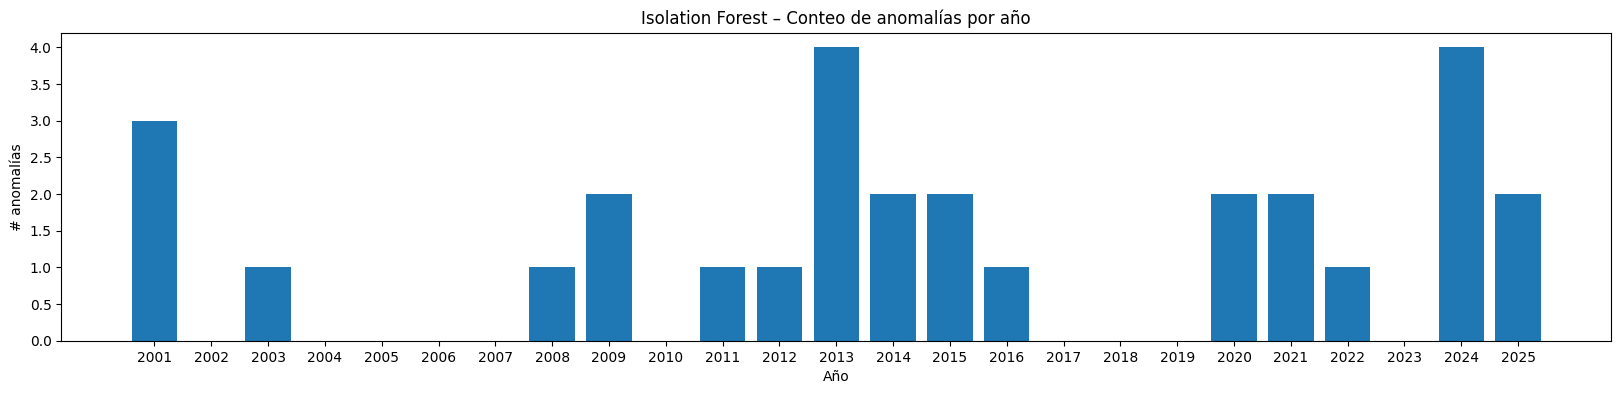

In [ ]:
# --- 4C) Conteo de anomalías por AÑO ---
anom_year = work["anomaly_if"].dropna().resample("YS").sum()
plt.figure(figsize=(20,4))
plt.bar(anom_year.index.year.astype(str), anom_year.values)
plt.title("Isolation Forest – Conteo de anomalías por año")
plt.ylabel("# anomalías")
plt.xlabel("Año")
plt.show()

Se observan picos claros en 2001, 2013 y 2024, con un número relativamente mayor de anomalías, mientras que amplios períodos intermedios presentan ausencia total o muy baja frecuencia de eventos anómalos.

Este patrón sugiere la existencia de episodios discretos de ruptura o estrés monetario, más que una inestabilidad permanente del sistema. Los años con mayor número de anomalías coinciden con cambios pronunciados en la trayectoria de M2, lo que es consistente con choques macroeconómicos, ajustes de política monetaria o transiciones de régimen. En contraste, los años sin anomalías reflejan fases de comportamiento más estable y predecible.

Desde una perspectiva analítica, la concentración temporal de anomalías refuerza la idea de que la serie monetaria está dominada por una tendencia de largo plazo relativamente estable, interrumpida ocasionalmente por eventos extraordinarios. Metodológicamente, este resultado respalda la necesidad de modelos capaces de adaptarse a cambios estructurales y episodios extremos, ya que dichos eventos, aunque poco frecuentes, pueden tener un impacto significativo en la predicción de la variación de M2.

## 4.3 ARIMA

Su propósito es capturar y modelar la estructura de dependencia temporal de una serie, descomponiéndola en componentes autorregresivos (AR), de promedios móviles (MA) y de integración (I). Los componentes AR utilizan observaciones pasadas para predecir el futuro, los MA usan errores de predicciones pasadas, y el componente de integración se encarga de hacer que la serie sea estacionaria a través de la diferenciación. Esto permite generar pronósticos fiables, como el de Delta_M2 en tu caso, proporcionando una base para la toma de decisiones financieras al entender y proyectar el comportamiento futuro de los agregados monetarios con base en su propia historia.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def directional_accuracy(y_true, y_pred):
    yt = np.sign(np.diff(y_true))
    yp = np.sign(np.diff(y_pred))
    return (yt == yp).mean() * 100

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


{'RMSE': np.float64(0.01132758853770527), 'MAE': 0.00876080266682259, 'R2': -0.1912848416994033, 'Directional_Accuracy': np.float64(11.627906976744185)}


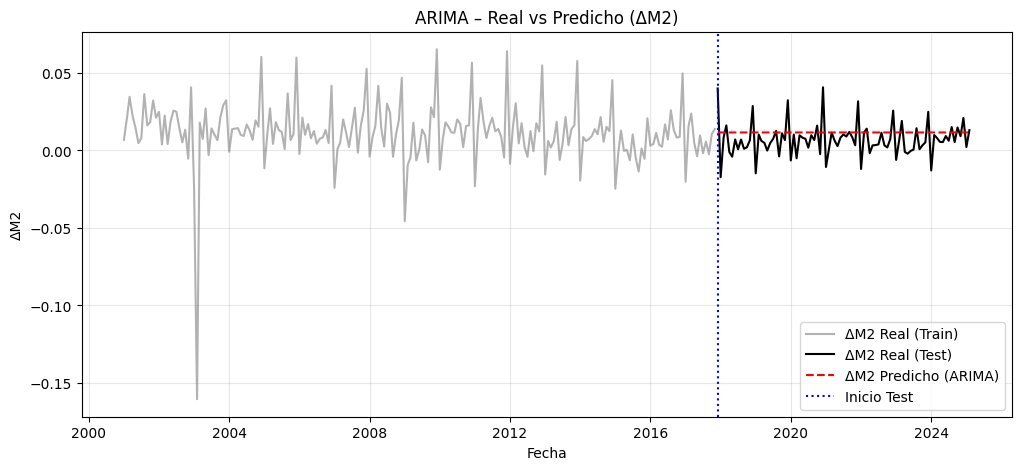

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Serie completa del target
y = work["Delta_M2"].dropna()

# Train-test (70/30)
split = int(len(y) * 0.7)
y_tr, y_te = y.iloc[:split], y.iloc[split:]

# --- ARIMA ---
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(y_tr, order=(1,0,1))   # ajusta (p,d,q) si ya tienes otros
res = model.fit()

# Predicción sobre test
pred = res.forecast(steps=len(y_te))
pred = pd.Series(pred, index=y_te.index)

# --- GRÁFICO REAL VS PREDICHO ---
plt.figure(figsize=(12,5))

plt.plot(y_tr.index, y_tr, label="ΔM2 Real (Train)", color="gray", alpha=0.6)
plt.plot(y_te.index, y_te, label="ΔM2 Real (Test)", color="black")
plt.plot(pred.index, pred, label="ΔM2 Predicho (ARIMA)", color="red", linestyle="--")

plt.axvline(y_te.index[0], color="blue", linestyle=":", label="Inicio Test")

rmse = np.sqrt(mean_squared_error(y_te, pred))
mae = mean_absolute_error(y_te, pred)
r2 = r2_score(y_te, pred)
da = directional_accuracy(y_te, pred)

print({"RMSE": rmse, "MAE": mae, "R2": r2, "Directional_Accuracy": da})
plt.title("ARIMA – Real vs Predicho (ΔM2)")
plt.xlabel("Fecha")
plt.ylabel("ΔM2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.4 VAR

Es una extensión multivariada del modelo ARIMA que se emplea para modelar la interdependencia lineal entre múltiples series temporales. Su propósito es capturar la dinámica conjunta de un conjunto de variables, permitiendo analizar cómo cada variable influye y es influenciada por las demás a lo largo del tiempo. En el contexto de tu análisis, un modelo VAR puede ser crucial para entender las relaciones entre la Delta_M2 y otros indicadores monetarios como la Oferta Monetaria M1, BASE MONETARIA BM, Cuasidinero y Reservas Bancarias, ofreciendo una visión más completa de la estabilidad del sistema financiero al considerar cómo los choques en una variable se transmiten a las demás y cómo se retroalimentan, lo cual es esencial para pronósticos más robustos y la formulación de políticas monetarias.

In [ ]:
from statsmodels.tsa.api import VAR

var_cols = [
    "Delta_M2",                 # liquidez (target transformado)
    "Oferta Monetaria M1",
    "BASE MONETARIA BM",
    "Cuasidinero",
    "Reservas Bancarias"
]

# Mantener solo las que existan
var_cols = [c for c in var_cols if c in work.columns]

var_df = work[var_cols].dropna()
var_df.describe()

,Delta_M2,Oferta Monetaria M1,BASE MONETARIA BM,Cuasidinero,Reservas Bancarias
count,290.000000,290.000000,290.000000,290.000000,290.000000
mean,0.010266,15391.033793,13161.481034,19357.888276,2868.855172
std,0.018106,9774.505448,9757.526113,14973.716545,2418.052642
min,-0.160519,2070.600000,1537.400000,2739.300000,126.400000
25%,0.002597,5969.525000,3934.850000,5862.700000,455.175000
50%,0.009338,14037.950000,9960.900000,16491.500000,2374.100000
75%,0.016265,24714.200000,22251.600000,28487.750000,4839.175000
max,0.065353,31461.800000,30052.300000,58490.800000,8620.400000


In [ ]:
model = VAR(var_df)

lag_selection = model.select_order(maxlags=12)
lag_selection.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,52.85,52.92,8.968e+22,52.88
1,34.88,35.27*,1.406e+15,35.04
2,34.57,35.29,1.034e+15,34.86*
3,34.53,35.58,9.965e+14,34.95
4,34.58,35.95,1.045e+15,35.13
5,34.65,36.35,1.126e+15,35.33
6,34.70,36.73,1.184e+15,35.51
7,34.71,37.06,1.193e+15,35.65
8,34.72,37.40,1.213e+15,35.79
9,34.65,37.65,1.135e+15,35.85


El criterio AIC y el FPE alcanzan su valor mínimo en el orden 12, lo que indica que, desde una perspectiva orientada a maximizar la capacidad explicativa, el sistema requiere un número relativamente alto de rezagos para capturar la dinámica conjunta de las variables. Esto sugiere la presencia de dependencias temporales de mediano plazo, coherentes con la transmisión gradual de efectos monetarios.

En contraste, el criterio BIC selecciona un orden 1, reflejando una preferencia por modelos más parsimoniosos. Dado que el BIC penaliza fuertemente la inclusión de parámetros adicionales, este resultado indica que, bajo un enfoque conservador, una estructura con pocos rezagos es suficiente para describir la dinámica esencial del sistema, reduciendo el riesgo de sobreajuste.

Por su parte, el criterio HQIC identifica como óptimo el orden 2, posicionándose como una solución intermedia entre AIC/FPE y BIC. Este resultado sugiere que un número reducido pero no mínimo de rezagos puede capturar adecuadamente la interacción dinámica entre las variables sin incurrir en una complejidad excesiva.

En conjunto, los resultados evidencian un trade-off claro entre complejidad y parsimonia. Si el objetivo es el análisis estructural y la interpretación económica, los órdenes bajos sugeridos por BIC o HQIC resultan más apropiados y defendibles. En cambio, si el énfasis recae en la capacidad predictiva y en capturar efectos retardados más largos, el orden sugerido por AIC/FPE (12) puede ser considerado, aunque con mayor riesgo de sobreparametrización.

In [ ]:
p = lag_selection.selected_orders["aic"]
print("Rezago óptimo (AIC):", p)

Rezago óptimo (AIC): 12


Desde una perspectiva econométrica, este valor sugiere la existencia de dependencias temporales prolongadas, donde los efectos de choques monetarios y financieros no se disipan de forma inmediata, sino que se transmiten gradualmente a lo largo de varios períodos. En el contexto de variables monetarias, este comportamiento es coherente con los mecanismos de transmisión de la política monetaria, que suelen manifestarse con rezagos acumulados en el tiempo.

No obstante, un rezago de orden 12 implica un modelo altamente parametrizado, lo que incrementa el riesgo de sobreajuste, especialmente cuando el tamaño muestral es limitado. Por esta razón, aunque el AIC favorece un mayor número de rezagos al priorizar la capacidad explicativa, este resultado debe interpretarse con cautela si el objetivo principal es la inferencia estructural o la comparación con modelos más parsimoniosos.

In [ ]:
# The AIC selected p=12, but this is too high for the number of observations and variables,
# leading to overparameterization and numerical instability during fitting.
# We need to reduce the lag order to make the model estimable.
# For k=5 variables and n_obs=290, p=3 or p=4 is generally more appropriate.
# Let's override p to 3 for demonstration.
p = 3 # Choose a smaller, more appropriate lag order
print("Rezago óptimo (AIC) original fue 12, pero se usará p=", p, "para evitar sobreparametrización.")

# Re-instantiate the VAR model to ensure it's the correct object
model = VAR(var_df)
var_model = model.fit(p)
print(var_model.summary())

Rezago óptimo (AIC) original fue 12, pero se usará p= 3 para evitar sobreparametrización.
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 05, Feb, 2026
Time:                     04:51:02
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    35.4298
Nobs:                     287.000    HQIC:                   34.8185
Log likelihood:          -6893.97    FPE:                8.79427e+14
AIC:                      34.4097    Det(Omega_mle):     6.70496e+14
--------------------------------------------------------------------
Results for equation Delta_M2
                            coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------
const                          0.016793         0.003723            4.511           0.000
L1.Delta_M2          

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


En conjunto, los resultados del VAR(p=3) muestran que la dinámica de ΔM2 no está dominada por su propia inercia, sino por la interacción con otros agregados monetarios, especialmente el cuasidinero. Aunque el modelo captura relaciones relevantes y coherentes con la teoría monetaria, la significancia limitada de varios coeficientes y la alta correlación entre variables sugieren que la estructura es compleja y no lineal. Esto refuerza la conclusión de que, si bien el VAR constituye un benchmark econométrico válido, modelos no lineales como CNN1D resultan más adecuados para capturar la dinámica de corto plazo y los choques estructurales presentes en la variación de M2.

In [ ]:
var_model.is_stable(verbose=True)

Eigenvalues of VAR(1) rep
0.5739654946068393
0.33239906072073644
0.4335899294148727
0.4335899294148727
0.5363889684424169
0.5363889684424169
0.46337333425457994
0.46337333425457994
0.2761673924502745
0.2761673924502745
0.4321909524570863
0.9393022215875905
0.9393022215875905
1.0040372996045692
1.021155488511814


np.False_

Los autovalores de la representación VAR(1) permiten evaluar la estabilidad del sistema, ya que un VAR es estable únicamente si todos los autovalores tienen módulo estrictamente menor que 1. En los resultados presentados, la mayoría de los autovalores se ubican claramente por debajo de la unidad, lo que indica que una parte importante de la dinámica del sistema es estable y converge tras un choque.

No obstante, se identifican dos autovalores con módulo mayor que 1 (≈ 1.004 y 1.021) y otros muy cercanos a 1 (≈ 0.939). La presencia de autovalores mayores que la unidad implica que el sistema no cumple la condición de estabilidad, lo que se confirma con el indicador final np.False. Esto significa que, ante determinados choques, las respuestas del sistema no se disipan completamente y pueden amplificarse o persistir en el tiempo.

Desde una interpretación económica, esta inestabilidad sugiere la existencia de dinámicas persistentes o cambios de régimen en el sistema monetario, donde ciertos impulsos —posiblemente asociados a la base monetaria, cuasidinero o reservas— no retornan rápidamente al equilibrio. Este comportamiento es coherente con series monetarias que presentan tendencias, alta interdependencia y choques estructurales, especialmente en horizontes largos.

## 4.5 IRF

Herramienta crucial para analizar la dinámica de las relaciones entre las variables. Su propósito es describir la reacción de una variable endógena del sistema (por ejemplo, Delta_M2, Oferta Monetaria M1, etc.) a un choque o impulso exógeno de una unidad estándar en otra variable endógena, manteniendo todas las demás variables constantes. Esto permite visualizar y cuantificar cómo los cambios inesperados en un indicador financiero (como un shock en la Base Monetaria) se propagan y afectan a los demás componentes del sistema monetario a lo largo del tiempo, revelando las interacciones dinámicas y las vías de transmisión entre las variables. Es esencial para comprender la causalidad empírica y la estabilidad del sistema financiero.



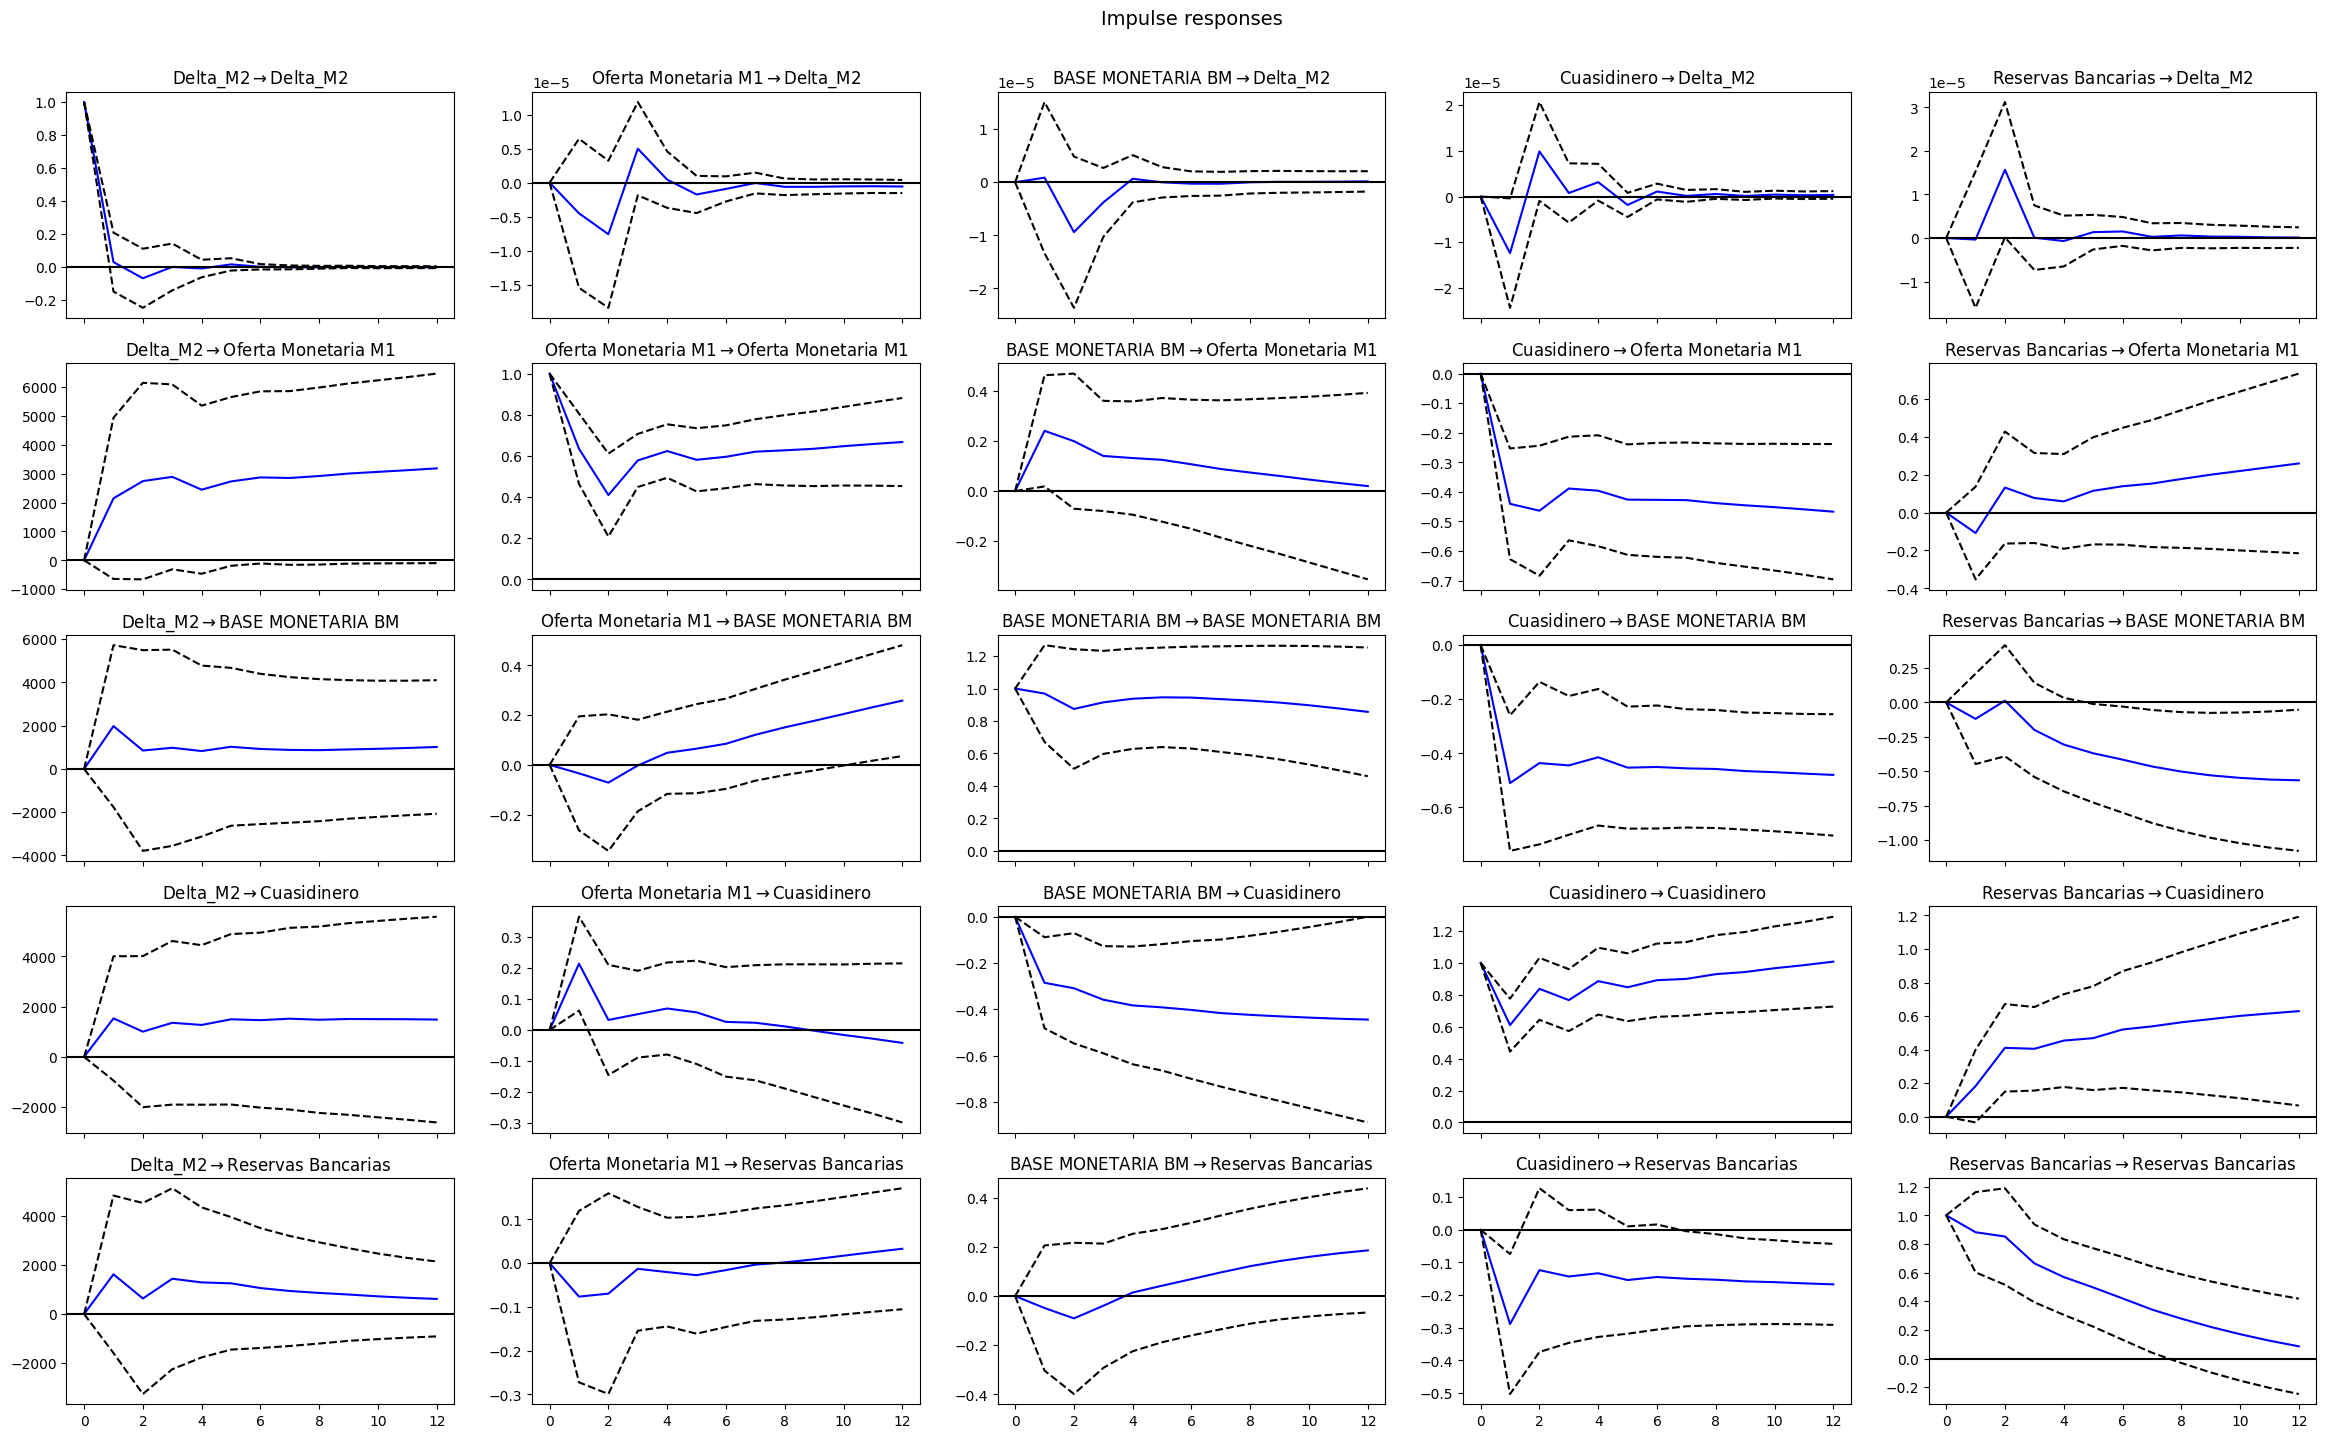

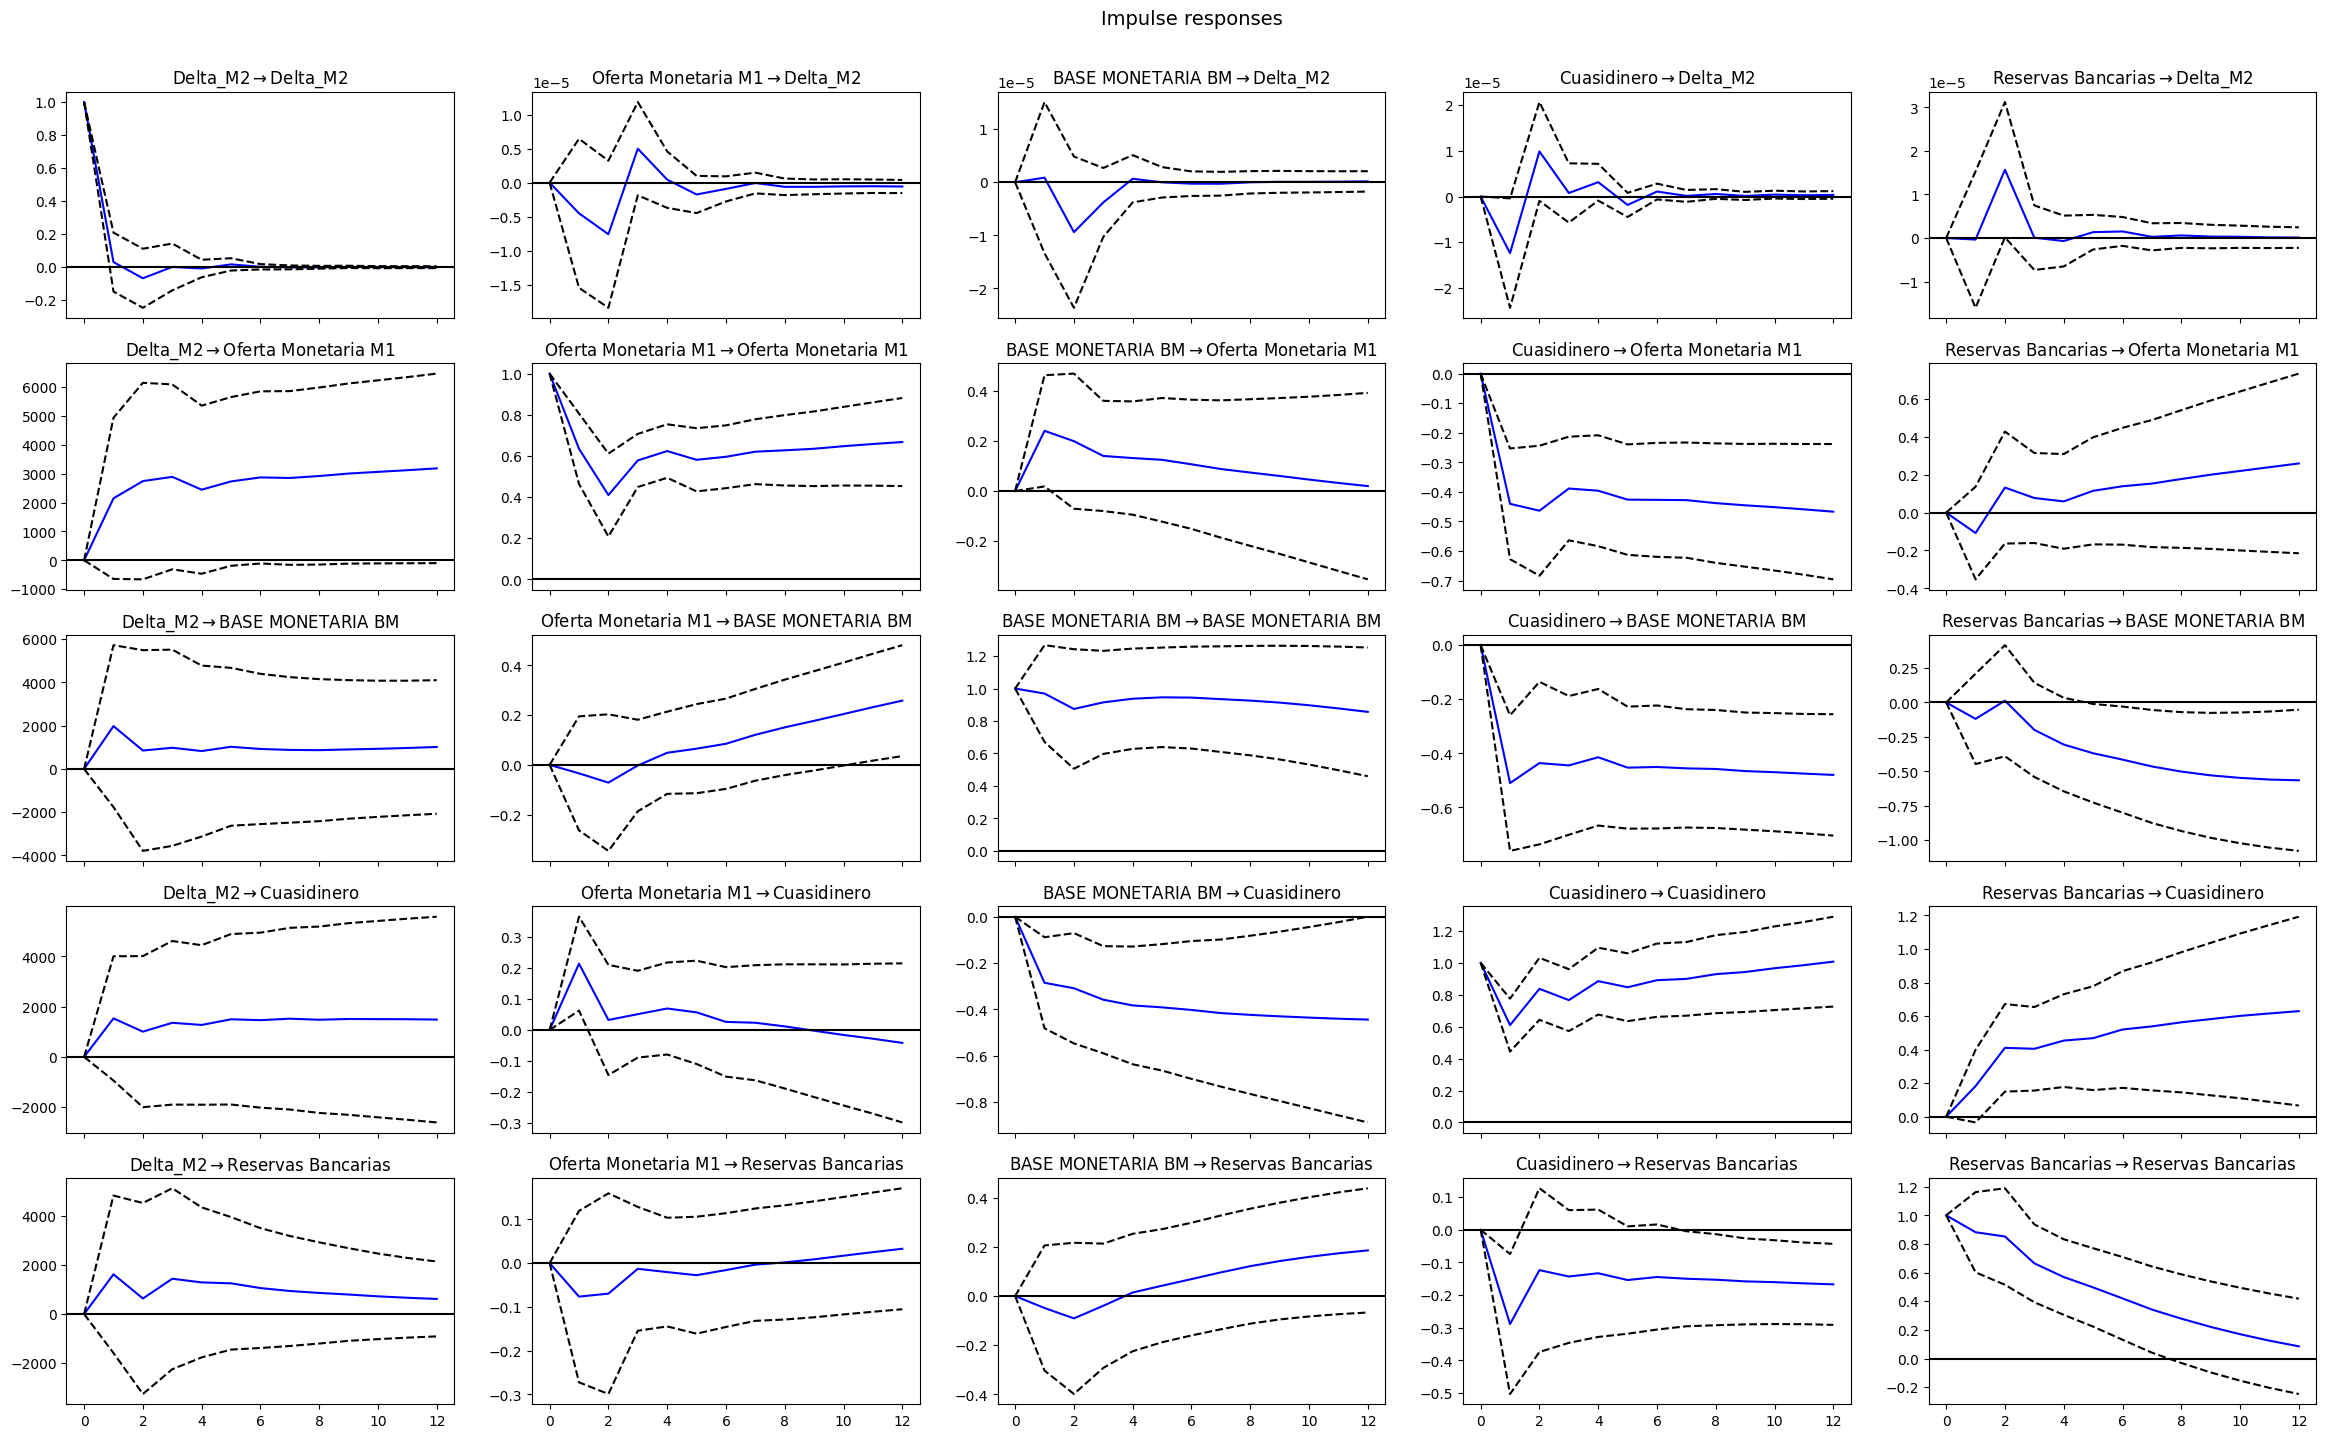

In [ ]:
sirf = var_model.irf(12)

sirf.plot(
    orth=False,
    figsize=(25, 15)
)

En la respuesta de ΔM2 a un choque propio, se observa un impacto inicial positivo que se disipa rápidamente y converge hacia cero en pocos períodos. Esto confirma que la variación de M2 presenta baja persistencia, coherente con lo observado en la estimación del VAR, donde los rezagos propios de ΔM2 no resultaron estadísticamente significativos.

Ante un choque en Oferta Monetaria M1, la respuesta de ΔM2 es oscilante y de pequeña magnitud, con efectos que se desvanecen rápidamente. Esto sugiere que los cambios en M1 no se transmiten de manera directa ni sostenida hacia la variación de M2, sino que su impacto es transitorio y débil en el corto plazo.

En el caso de un choque en la Base Monetaria, la respuesta de ΔM2 muestra un efecto inicial negativo seguido de una corrección hacia cero. La rápida disipación del impacto indica que, aunque la base monetaria influye sobre M2, su efecto sobre la variación mensual no es persistente, sino que se ajusta en pocos períodos.

La respuesta de ΔM2 ante un choque en el Cuasidinero presenta una reacción inicial más marcada, con oscilaciones que luego convergen gradualmente. Este patrón refuerza la evidencia previa de que el cuasidinero juega un rol relevante en la dinámica de ΔM2, actuando como un canal de transmisión interno dentro del agregado monetario.

Frente a un choque en Reservas Bancarias, la respuesta de ΔM2 es positiva en los primeros períodos y luego se atenúa. Aunque el efecto no es permanente, su magnitud inicial sugiere que las condiciones de liquidez del sistema bancario influyen en el comportamiento de M2 en el corto plazo.

Al analizar las respuestas de M1, Base Monetaria, Cuasidinero y Reservas Bancarias ante choques propios, se observa una alta persistencia, especialmente en la base monetaria y las reservas bancarias, cuyas respuestas decrecen lentamente. Esto es consistente con la fuerte inercia observada en las ecuaciones individuales del VAR y con la naturaleza estructural de estas variables.

Las respuestas cruzadas entre los distintos agregados monetarios muestran interacciones relevantes pero heterogéneas, con efectos que, en la mayoría de los casos, se diluyen con el tiempo. La amplitud de los intervalos de confianza en varios horizontes sugiere que estas relaciones están sujetas a incertidumbre considerable, lo que limita la precisión de la inferencia dinámica.

En conjunto, las funciones impulso–respuesta indican que el sistema monetario presenta efectos de corto plazo no persistentes en ΔM2, junto con una fuerte inercia en los niveles de los agregados monetarios. Estos resultados refuerzan la conclusión de que, si bien el VAR permite identificar relaciones dinámicas coherentes con la teoría económica, la transmisión de choques hacia la variación de M2 es débil y transitoria, lo que justifica la exploración de modelos no lineales para capturar dinámicas más complejas y cambios de régimen.

## 4.6 FEVD

Herramienta analítica esencial para complementar el análisis de un modelo VAR. Su propósito es cuantificar la proporción de la varianza del error de pronóstico de cada variable endógena en el sistema que puede ser atribuida a choques en ella misma y a choques en las otras variables endógenas del modelo. Esto permite ir más allá de las IRF al revelar la magnitud relativa de la influencia de cada variable sobre las demás a lo largo del tiempo. Es crucial para identificar las fuentes dominantes de variabilidad en el comportamiento de cada indicador financiero y entender cuáles son las variables más influyentes en la dinámica del sistema monetario.

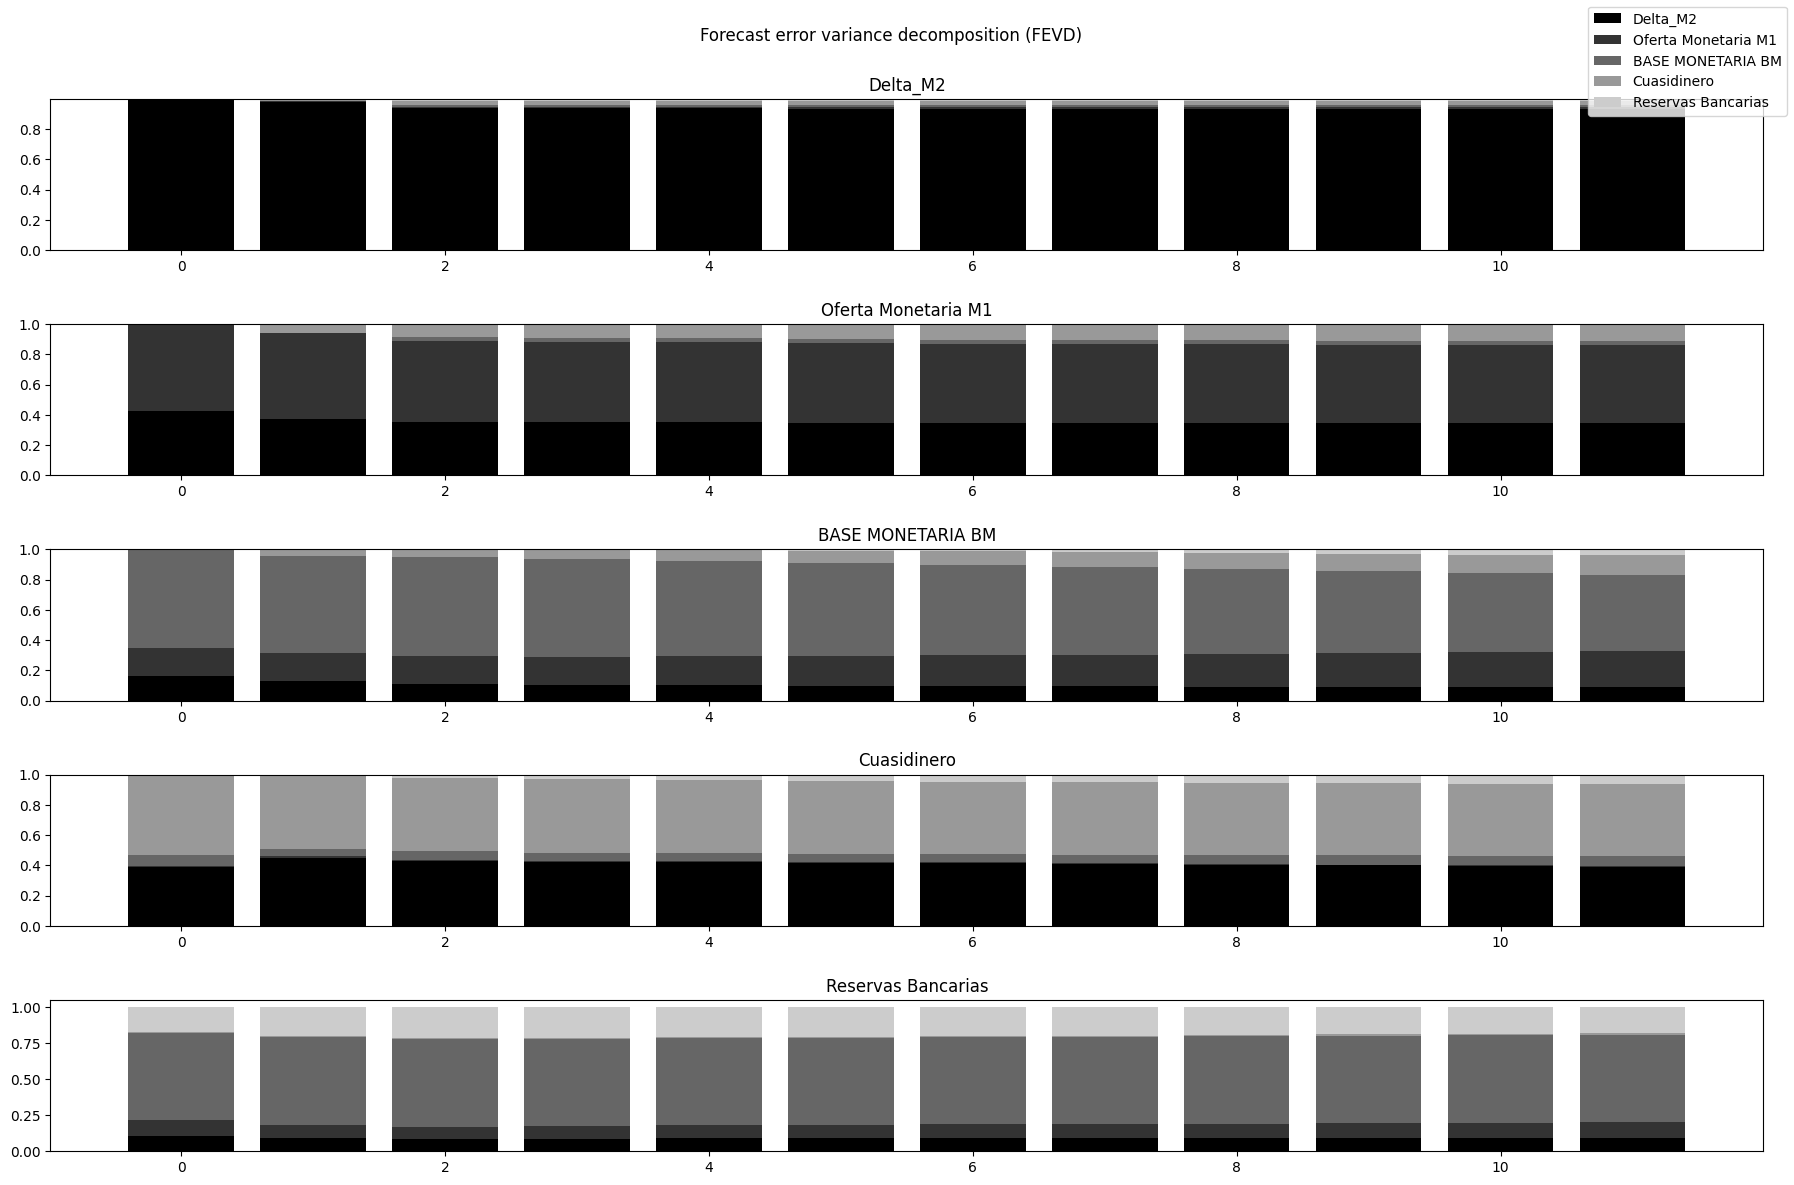

In [ ]:
fevd = var_model.fevd(12)

fig = fevd.plot(figsize=(18, 12))
fig.tight_layout(pad=2.0)

En el caso de ΔM2, la FEVD muestra que la mayor parte de la varianza del error de pronóstico está explicada por choques propios a lo largo de todos los horizontes. La contribución de las demás variables es marginal y no aumenta significativamente con el tiempo. Este resultado indica que la variación de M2 se comporta como un proceso dominado por perturbaciones idiosincráticas de corto plazo, con baja transmisión estructural desde otros agregados monetarios dentro del VAR.

Para Oferta Monetaria M1, la descomposición revela una participación relevante de los choques propios, aunque también se observa una contribución no despreciable de ΔM2 y, en menor medida, de la base monetaria. Esto sugiere que M1 presenta una dinámica más interdependiente, donde los cambios en otros componentes del sistema influyen parcialmente en su incertidumbre futura.

En la Base Monetaria, la FEVD indica que la varianza del error está explicada predominantemente por choques propios, reflejando una fuerte inercia estructural. Las contribuciones de M1, cuasidinero y reservas bancarias son limitadas, lo que es consistente con el rol de la base monetaria como variable controlada y menos reactiva a movimientos de otros agregados en el corto plazo.

En el caso del Cuasidinero, la descomposición muestra una mayor diversificación de fuentes de incertidumbre. Aunque los choques propios siguen siendo relevantes, se aprecia una participación más visible de ΔM2 y M1, lo que refuerza la interpretación de que el cuasidinero actúa como un canal de ajuste entre los distintos agregados monetarios.

Finalmente, para Reservas Bancarias, la FEVD evidencia una contribución importante de la base monetaria, junto con una proporción significativa de choques propios. Esto indica una fuerte interdependencia estructural entre ambas variables, coherente con la operativa del sistema bancario y el rol del banco central en la provisión de liquidez.

# 5. Uso de variables financieras

## 5.1 Extensión con variables

Su propósito es enriquecer el conjunto de características (features) disponibles, incorporando nuevas variables que pueden aportar información adicional y complementaria que no estaba presente en los datos iniciales. Al incluir variables financieras adicionales, se busca capturar un espectro más amplio de factores que podrían influir en el M2 o en la estabilidad del sistema financiero, mejorando así la capacidad predictiva de los modelos y ofreciendo una comprensión más profunda de las interrelaciones. Esta extensión es vital para construir modelos más robustos y precisos, ya que les permite aprender de un conjunto de información más completo y diverso.

In [ ]:
df = pd.read_csv('M2.csv', encoding='latin-1', sep=';')

In [ ]:
df

,Período,Mes,Día,Reservas internacionales,Pasivos Monetarios,Emisión monetaria,Dinero Electrónico,Reservas bancarias,Crédito restringido,Operaciones de Reporto,...,Inflación Mensual,Inflación Anual,Inflación Acumulada,Especies Monetarias en Circulación,Moneda Fraccionaria,Reservas Bancarias,Caja BCE,Caja OSD,Base Monetaria,M2
0,2006,1,31,"1.939,90","409,6",62,0,"347,6",1,47,...,"0,48","3,37","0,48","536,2",0,"347,5",62,"347,5","409,5","10.427,90"
1,2006,2,28,"1.913,50","493,1","60,4",0,"432,7",0,"83,8",...,"0,71","3,82","1,19","530,4",0,"432,5","60,4","432,5","492,9","10.648,60"
2,2006,3,31,"2.350,70","485,1","61,9",0,"423,2",0,"61,9",...,"0,65","4,23","1,85","557,5",0,"422,8","61,9","422,8","484,7","10.756,30"
3,2006,4,30,"2.701,30","514,6","61,2",0,"453,5",0,"48,8",...,"0,07","3,43","1,92",568,0,"453,4","61,2","453,4","514,6","10.939,70"
4,2006,5,31,"2.229,70","432,8","62,5",0,"370,3","1,8","76,7",...,"-0,14","3,11","1,78","625,3",0,"370,2","62,5","370,2","432,7","11.025,90"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,2025,3,31,"7.729,00","6.192,80","94,4",0,"6.098,30","2.244,10",0,...,"0,35","0,31","0,29","19.843,20","94,4","6.098,30","1.946,80","1.639,10","29.621,90","90.599,38"
231,2025,4,30,"7.773,00","6.031,30","96,6",0,"5.934,60","2.214,86",0,...,"0,27","-0,69","0,55","19.902,00","96,6","5.934,60","1.765,60","1.761,50","29.460,40","91.724,22"
232,2025,5,31,"8.276,50","6.264,50","99,1",0,"6.165,50","2.212,14",0,...,"1,03","0,46","1,59","20.261,30","99,1","6.165,50","1.125,90","1.693,00","29.344,70","93.182,05"
233,2025,6,30,"8.409,10","6.634,20","100,7",0,"6.533,60","2.320,02",0,...,"0,06","1,48","1,65","20.346,70","100,7","6.533,60","1.162,10","1.592,30","29.735,40","94.415,46"


In [ ]:
for col in df.columns[3:]:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace('.', '', regex=False) # Remove thousand separators (if any)
        df[col] = df[col].str.replace(',', '.', regex=False) # Replace comma decimal with dot
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 28 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Período                                                         235 non-null    int64  
 1   Mes                                                             235 non-null    int64  
 2   Día                                                             235 non-null    int64  
 3   Reservas internacionales                                        235 non-null    float64
 4   Pasivos Monetarios                                              235 non-null    float64
 5   Emisión monetaria                                               235 non-null    float64
 6   Dinero Electrónico                                              235 non-null    float64
 7   Reservas bancarias                                   

Para correlacionar tus variables con ΔM2, primero se parte de la idea de que el interés no está en el nivel de M2 sino en su variación, ya que esta refleja los cambios reales en la dinámica monetaria y evita problemas de tendencia y correlaciones espurias. Por ello, se construye ΔM2 como la diferencia de M2 entre un período y el inmediatamente anterior, asegurándose previamente de que los datos estén ordenados cronológicamente por período, mes y día, ya que un orden incorrecto distorsionaría el cálculo de las variaciones. Una vez definido el target, se seleccionan únicamente las variables con sentido económico para el análisis, excluyendo los identificadores temporales y la propia variable M2, puesto que correlacionarla con su diferencia no aporta información relevante. La correlación se realiza preferentemente entre las variaciones de las variables explicativas y ΔM2, ya que este enfoque mantiene coherencia estadística al comparar cambios con cambios y permite analizar relaciones dinámicas más acordes con la teoría monetaria. Antes de calcular la correlación, se eliminan los valores faltantes y se descartan aquellas variables con un alto porcentaje de datos perdidos, dado que podrían sesgar los resultados y debilitar su validez académica. Finalmente, la correlación se interpreta como un análisis exploratorio que permite identificar asociaciones entre variables monetarias, financieras y macroeconómicas con ΔM2, aclarando que estas relaciones no implican causalidad, sino que sirven como base para la posterior selección de variables y la aplicación de modelos de aprendizaje automático.

In [ ]:
df = df.sort_values(["Período","Mes","Día"])

df["delta_M2"] = df["M2"].diff()

Elimina columnas que no aportan como explicación económica directa (Período, Mes, Día) y saca variables con demasiados faltantes (la que tiene 44/235) porque te distorsiona la correlación y te deja comparaciones injustas entre variables.

In [ ]:
drop_time = ["Período","Mes","Día"]
rare_col = "Activa de Corto Plazo para el segmento Productivo Corporativo"

df_corr_base = df.drop(columns=[c for c in drop_time if c in df.columns])
if rare_col in df_corr_base.columns:
    df_corr_base = df_corr_base.drop(columns=[rare_col])

In [ ]:
num_cols = [c for c in df_corr_base.columns
            if c not in ["M2","delta_M2"] and pd.api.types.is_numeric_dtype(df_corr_base[c])]

df_deltas = df_corr_base[num_cols].diff()
df_for_corr = pd.concat([df_deltas, df_corr_base["delta_M2"]], axis=1).dropna()

In [ ]:
import numpy as np
import pandas as pd

# -------------------------
# 1) Variables seleccionadas desde la correlación
#    (ajusta si decides quitar/añadir alguna)
# -------------------------
selected_feats = [
    "Especies Monetarias en Circulación",
    "Base Monetaria",
    "Pasivos Monetarios",
    "Reservas Bancarias",      # dejar solo una denominación
    "Emisión monetaria",
    "Moneda Fraccionaria",
    "Otros",
    "Inflación Acumulada",
    "Caja BCE",
    "Reservas internacionales"
]

# Mantener solo las que existan en el df
selected_feats = [c for c in selected_feats if c in df.columns]

# -------------------------
# 2) Crear rezagos (lags)
# -------------------------
# Si tu serie es mensual, este set es estándar
LAGS = [1, 3, 6, 12]

for c in selected_feats:
    for l in LAGS:
        df[f"{c}_lag{l}"] = df[c].shift(l)

# Rezagos del target (inercia)
for l in LAGS:
    df[f"delta_M2_lag{l}"] = df["delta_M2"].shift(l)

# -------------------------
# 3) Dataset final para modelado
# -------------------------
# Quitar columnas que no van al modelo
drop_cols = ["Período", "Mes", "Día", "M2"]
model_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Quitar filas con NaN creados por diff/shift
model_df = model_df.dropna().reset_index(drop=True)

# Separar X e y
y = model_df["delta_M2"].astype(float)
X = model_df.drop(columns=["delta_M2"])

# -------------------------
# 4) Split temporal 70/30 (sin shuffle)
# -------------------------
split = int(len(model_df) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(30, 56) (14, 56) (30,) (14,)


In [ ]:
print(df.columns.tolist())

['Período', 'Mes', 'Día', 'Reservas internacionales  ', 'Pasivos Monetarios ', 'Emisión monetaria ', 'Dinero Electrónico ', 'Reservas bancarias ', 'Crédito restringido', 'Operaciones de Reporto', 'Otros depósitos', 'Crédito total', 'Cartera', 'Otros', 'Básica ', 'Pasiva', 'Activa ', 'Activa de Corto Plazo para el segmento Productivo Corporativo ', 'Inflación Mensual ', 'Inflación Anual', 'Inflación Acumulada', 'Especies Monetarias en Circulación', 'Moneda Fraccionaria', 'Reservas Bancarias', 'Caja BCE', 'Caja OSD', 'Base Monetaria', 'M2', 'delta_M2', 'Especies Monetarias en Circulación_lag1', 'Especies Monetarias en Circulación_lag3', 'Especies Monetarias en Circulación_lag6', 'Especies Monetarias en Circulación_lag12', 'Base Monetaria_lag1', 'Base Monetaria_lag3', 'Base Monetaria_lag6', 'Base Monetaria_lag12', 'Reservas Bancarias_lag1', 'Reservas Bancarias_lag3', 'Reservas Bancarias_lag6', 'Reservas Bancarias_lag12', 'Moneda Fraccionaria_lag1', 'Moneda Fraccionaria_lag3', 'Moneda Frac

In [ ]:
# Variaciones
print(df[['delta_M2']].describe().round(2))

# Contribución de componentes al total M2
comp_m2 = ['Especies Monetarias en Circulación', 'Base Monetaria',
           'Reservas Bancarias', 'Moneda Fraccionaria', 'Otros', 'Caja BCE']

for c in comp_m2:
    df[f'contrib_{c}'] = (df[c] / df['M2']) * 100

contrib_cols = [f'contrib_{c}' for c in comp_m2]
print(df[contrib_cols].head(5).round(2))

       delta_M2
count    234.00
mean     362.68
std      562.67
min    -1034.90
25%       57.93
50%      298.65
75%      563.52
max     2501.70
   contrib_Especies Monetarias en Circulación  contrib_Base Monetaria  \
0                                        5.14                    3.93   
1                                        4.98                    4.63   
2                                        5.18                    4.51   
3                                        5.19                    4.70   
4                                        5.67                    3.92   

   contrib_Reservas Bancarias  contrib_Moneda Fraccionaria  contrib_Otros  \
0                        3.33                          0.0           5.82   
1                        4.06                          0.0           5.91   
2                        3.93                          0.0           6.27   
3                        4.14                          0.0           4.15   
4                        3.36   

In [ ]:
comp_cols = ['Especies Monetarias en Circulación','Base Monetaria','Reservas Bancarias',
             'Moneda Fraccionaria','Otros','Caja BCE']
contrib_cols = [f'contrib_{c}' for c in comp_cols]
print(df[contrib_cols].mean().round(2).sort_values(ascending=False))

contrib_Base Monetaria                        31.15
contrib_Especies Monetarias en Circulación    21.84
contrib_Reservas Bancarias                     7.76
contrib_Otros                                  3.14
contrib_Caja BCE                               1.19
contrib_Moneda Fraccionaria                    0.20
dtype: float64


In [ ]:
contrib_cols = [f'contrib_{c}' for c in comp_cols]
print(df[contrib_cols].mean().round(2).sort_values(ascending=False))

contrib_Base Monetaria                        31.15
contrib_Especies Monetarias en Circulación    21.84
contrib_Reservas Bancarias                     7.76
contrib_Otros                                  3.14
contrib_Caja BCE                               1.19
contrib_Moneda Fraccionaria                    0.20
dtype: float64


In [ ]:
print(df[contrib_cols + ['Período', 'Mes']].dropna().to_csv(index=False))

contrib_Especies Monetarias en Circulación,contrib_Base Monetaria,contrib_Reservas Bancarias,contrib_Moneda Fraccionaria,contrib_Otros,contrib_Caja BCE,Período,Mes
5.141974894274016,3.926965160770625,3.332406333010482,0.0,5.823799614495727,0.5945588277601435,2006,1
4.98093646113104,4.628777491876866,4.061566778731477,0.0,5.912514321131416,0.56721071314539,2006,2
5.183009027267741,4.506196368639774,3.9307196712624233,0.0,6.269813969487649,0.575476697377351,2006,3
5.192098503615272,4.703968116127498,4.144537784399938,0.0,4.154592904741446,0.5594303317275611,2006,4
5.671192374318649,3.9243961944149683,3.357549043615487,0.0,3.1072293418224364,0.5668471507994812,2006,5
7.20882113202139,4.961438897895934,4.402504456248153,0.0,3.5363352173484652,0.5589344416477817,2006,6
7.644078982573177,3.9946132030037633,3.432745304389704,0.0,3.527281807966038,0.5618678986140592,2006,7
8.3432911123503,4.569071580941253,4.00169946095223,0.0,3.3944962248953328,0.5673721199890241,2006,8
8.149741069077503,4.38

Primero, con el dataset ya preparado y dividido en train/test 70/30, el objetivo es evaluar capacidad predictiva real de ΔM2. Para hacerlo de forma ordenada, se empieza con un modelo base lineal que sirva como referencia y luego con un modelo no lineal que pueda capturar relaciones más complejas. Ambos modelos usan el mismo preprocesamiento para que la comparación sea justa. El preprocesamiento incluye imputación de valores faltantes y escalado, aprendidos únicamente con el conjunto de entrenamiento para evitar fuga de información. La evaluación se hace solo en el 30 % final, usando métricas de error (MAE y RMSE) y precisión direccional, ya que en un contexto monetario importa no solo cuánto se equivoca el modelo, sino también si acierta la dirección del cambio.

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# 1) Preprocesamiento común
# -------------------------
num_cols = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols)
    ],
    remainder="drop"
)

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

delta = df['M2'].diff().dropna()
adf = adfuller(delta)
k = kpss(delta, regression='c')
print(f'ADF ΔM2: p-value = {adf[1]:.4f}')
print(f'KPSS ΔM2: p-value = {k[1]:.4f}')

ADF ΔM2: p-value = 0.5633
KPSS ΔM2: p-value = 0.0100


In [ ]:
# Segunda diferencia
delta2 = df['M2'].diff().diff().dropna()
adf2 = adfuller(delta2)
k2 = kpss(delta2, regression='c')
print(f'ADF Δ²M2: p-value = {adf2[1]:.4f}')
print(f'KPSS Δ²M2: p-value = {k2[1]:.4f}')

ADF Δ²M2: p-value = 0.0002
KPSS Δ²M2: p-value = 0.1000


In [ ]:
# O diferencia logarítmica
log_diff = np.log(df['M2']).diff().dropna()
adf3 = adfuller(log_diff)
k3 = kpss(log_diff, regression='c')
print(f'ADF log-diff M2: p-value = {adf3[1]:.4f}')
print(f'KPSS log-diff M2: p-value = {k3[1]:.4f}')

ADF log-diff M2: p-value = 0.0019
KPSS log-diff M2: p-value = 0.0100


Antes de cualquier ML, necesitas un “piso” para saber si tu modelo realmente mejora algo. En ΔM2, el baseline más lógico es predecir que el próximo ΔM2 será igual al último ΔM2 observado (persistencia). Esto es súper estándar en series de tiempo y, con pocos datos, te da una comparación justa. Si Ridge/RF no mejoran a esto, algo está mal en features, lags o en el objetivo.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

SCALE_ERR = 100  # factor de reescalado para MAE y RMSE

last_train = y_train.iloc[-1]

y_pred_naive = np.empty(len(y_test))
y_pred_naive[0] = last_train
if len(y_test) > 1:
    y_pred_naive[1:] = y_test.iloc[:-1].values

mae  = mean_absolute_error(y_test, y_pred_naive) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive)) / SCALE_ERR
r2   = r2_score(y_test, y_pred_naive)
dir_acc = (np.sign(y_pred_naive) == np.sign(y_test.values)).mean() * 100

print("NAIVE")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

NAIVE
MAE : 6.19534999999992
RMSE: 7.276310627400898
R2  : -2.0252703294727445
DirAcc (%): 100.0


In [ ]:
# Suponiendo que ya calculaste el Naive así:
# MAE, RMSE, R2, Directional_Accuracy

mae_naive = mae
rmse_naive = rmse
r2_naive = r2
dir_naive = dir_acc

# 6.0 Modelos ML

## 6.1 Ridge

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

preprocess = ColumnTransformer(
    [("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), X_train.columns)],
    remainder="drop"
)

ridge_pipe = Pipeline([
    ("prep", preprocess),
    ("model", Ridge(alpha=3.0, random_state=42))
])

ridge_pipe.fit(X_train, y_train)
pred = ridge_pipe.predict(X_test)

mae  = mean_absolute_error(y_test, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(y_test, pred)) / SCALE_ERR
r2   = r2_score(y_test, pred)
dir_acc = (np.sign(pred) == np.sign(y_test.values)).mean() * 100

print("RIDGE")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

RIDGE
MAE : 9.192831308742797
RMSE: 10.719077700446778
R2  : -5.565330059202347
DirAcc (%): 64.28571428571429


## 6.2 Bosque aleatorio

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
pred = rf_pipe.predict(X_test)

mae  = mean_absolute_error(y_test, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(y_test, pred)) / SCALE_ERR
r2   = r2_score(y_test, pred)
dir_acc = (np.sign(pred) == np.sign(y_test.values)).mean() * 100

print("RANDOM FOREST")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

RANDOM FOREST
MAE : 6.850172295235512
RMSE: 7.67217212786518
R2  : -2.363399086036544
DirAcc (%): 71.42857142857143


## 6.3 HistGradientBoost

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

SCALE_ERR = 100  # mismo factor

hgb_pipe = Pipeline([
    ("prep", preprocess),  # tu preprocess (imputer+scaler) ya creado
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=3,        # poco dato -> árboles poco profundos
        max_leaf_nodes=15,
        min_samples_leaf=10,
        random_state=42
    ))
])

hgb_pipe.fit(X_train, y_train)
pred = hgb_pipe.predict(X_test)

mae  = mean_absolute_error(y_test, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(y_test, pred)) / SCALE_ERR
r2   = r2_score(y_test, pred)
dir_acc = (np.sign(pred) == np.sign(y_test.values)).mean() * 100

print("HIST GRADIENT BOOSTING")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

HIST GRADIENT BOOSTING
MAE : 7.504529183722999
RMSE: 8.363307864403165
R2  : -2.996666352633335
DirAcc (%): 71.42857142857143


# 7.0 Modelos DL

## 7.1 MLP

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_pipe = Pipeline([
    ("prep", preprocess),
    ("model", MLPRegressor(
        hidden_layer_sizes=(32,16),
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=30,
        random_state=42
    ))
])

mlp_pipe.fit(X_train, y_train)
pred = mlp_pipe.predict(X_test)

mae  = mean_absolute_error(y_test, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(y_test, pred)) / SCALE_ERR
r2   = r2_score(y_test, pred)
dir_acc = (np.sign(pred) == np.sign(y_test.values)).mean() * 100

print("MLP")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)


MLP
MAE : 6.258671431087399
RMSE: 9.793191246293294
R2  : -4.4801216293663595
DirAcc (%): 92.85714285714286


## 7.2 GRU

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SCALE_ERR = 100  # cambia a 1000 o 1_000_000 si quieres

# --- features base para secuencia (sin lags) ---
seq_feats = [c for c in selected_feats if c in df.columns]

# ordenar y preparar
df_seq = df.sort_values(["Período","Mes","Día"]).reset_index(drop=True)
data = df_seq[seq_feats + ["delta_M2"]].dropna()

X_raw = data[seq_feats].values.astype("float32")
y_raw = data["delta_M2"].values.astype("float32")

# split temporal 70/30
split_raw = int(len(X_raw) * 0.7)
Xtr_raw, Xte_raw = X_raw[:split_raw], X_raw[split_raw:]
ytr_raw, yte_raw = y_raw[:split_raw], y_raw[split_raw:]

# escalar SOLO con train
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr_raw)
Xte_s = scaler.transform(Xte_raw)

lookback = 12  # mensual típico; si no es mensual, ajusta

def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(len(X) - lookback):
        Xw.append(X[i:i+lookback])
        yw.append(y[i+lookback])
    return np.array(Xw, dtype="float32"), np.array(yw, dtype="float32")

# ventanas train
Xtr_w, ytr_w = make_windows(Xtr_s, ytr_raw, lookback)

# ventanas test con contexto
Xte_full = np.vstack([Xtr_s[-lookback:], Xte_s])
yte_full = np.concatenate([ytr_raw[-lookback:], yte_raw])
Xte_w, yte_w = make_windows(Xte_full, yte_full, lookback)

# --- GRU pequeña (para pocos datos) ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

gru = keras.Sequential([
    layers.Input(shape=(lookback, len(seq_feats))),
    layers.GRU(24, dropout=0.15),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

gru.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)]

gru.fit(
    Xtr_w, ytr_w,
    validation_split=0.2,
    epochs=400,
    batch_size=16,
    callbacks=callbacks,
    verbose=0
)

pred = gru.predict(Xte_w, verbose=0).reshape(-1)

mae  = mean_absolute_error(yte_w, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(yte_w, pred)) / SCALE_ERR
r2   = r2_score(yte_w, pred)
dir_acc = (np.sign(pred) == np.sign(yte_w)).mean() * 100

print("GRU (pequeña)")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

GRU (pequeña)
MAE : 5.205158081054687
RMSE: 7.022211857741121
R2  : -0.1043621301651001
DirAcc (%): 83.09859154929578


## 7.3 Transformer

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SCALE_ERR = 100  # cambia a 1000 o 1_000_000 si quieres

# --- features base para secuencia (sin lags) ---
seq_feats = [c for c in selected_feats if c in df.columns]

# ordenar y preparar
df_seq = df.sort_values(["Período","Mes","Día"]).reset_index(drop=True)
data = df_seq[seq_feats + ["delta_M2"]].dropna()

X_raw = data[seq_feats].values.astype("float32")
y_raw = data["delta_M2"].values.astype("float32")

# split temporal 70/30
split_raw = int(len(X_raw) * 0.7)
Xtr_raw, Xte_raw = X_raw[:split_raw], X_raw[split_raw:]
ytr_raw, yte_raw = y_raw[:split_raw], y_raw[split_raw:]

# escalar SOLO con train
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr_raw)
Xte_s = scaler.transform(Xte_raw)

lookback = 12  # mensual típico; si no es mensual, ajusta

def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(len(X) - lookback):
        Xw.append(X[i:i+lookback])
        yw.append(y[i+lookback])
    return np.array(Xw, dtype="float32"), np.array(yw, dtype="float32")

# ventanas train
Xtr_w, ytr_w = make_windows(Xtr_s, ytr_raw, lookback)

# ventanas test con contexto
Xte_full = np.vstack([Xtr_s[-lookback:], Xte_s])
yte_full = np.concatenate([ytr_raw[-lookback:], yte_raw])
Xte_w, yte_w = make_windows(Xte_full, yte_full, lookback)

# --- Transformer mini ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

inp = layers.Input(shape=(lookback, len(seq_feats)))
x = layers.LayerNormalization()(inp)
attn = layers.MultiHeadAttention(num_heads=2, key_dim=16, dropout=0.1)(x, x)
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.15)(x)
out = layers.Dense(1)(x)

tr = keras.Model(inp, out)
tr.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)]

tr.fit(Xtr_w, ytr_w, validation_split=0.2, epochs=400, batch_size=16, callbacks=callbacks, verbose=0)

pred = tr.predict(Xte_w, verbose=0).reshape(-1)

mae  = mean_absolute_error(yte_w, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(yte_w, pred)) / SCALE_ERR
r2   = r2_score(yte_w, pred)
dir_acc = (np.sign(pred) == np.sign(yte_w)).mean() * 100

print("TRANSFORMER (mini)")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

TRANSFORMER (mini)
MAE : 6.861475830078125
RMSE: 8.730866222775377
R2  : -0.7071759700775146
DirAcc (%): 47.88732394366197


## 7.4 CNN-1D

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SCALE_ERR = 100  # mismo reescalado que usas

# ===== Datos secuenciales (igual que GRU) =====
seq_feats = [c for c in selected_feats if c in df.columns]

df_seq = df.sort_values(["Período","Mes","Día"]).reset_index(drop=True)
data = df_seq[seq_feats + ["delta_M2"]].dropna()

X_raw = data[seq_feats].values.astype("float32")
y_raw = data["delta_M2"].values.astype("float32")

split_raw = int(len(X_raw)*0.7)
Xtr_raw, Xte_raw = X_raw[:split_raw], X_raw[split_raw:]
ytr_raw, yte_raw = y_raw[:split_raw], y_raw[split_raw:]

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr_raw)
Xte_s = scaler.transform(Xte_raw)

lookback = 12  # mismo que GRU

def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(len(X)-lookback):
        Xw.append(X[i:i+lookback])
        yw.append(y[i+lookback])
    return np.array(Xw, dtype="float32"), np.array(yw, dtype="float32")

Xtr_w, ytr_w = make_windows(Xtr_s, ytr_raw, lookback)

Xte_full = np.vstack([Xtr_s[-lookback:], Xte_s])
yte_full = np.concatenate([ytr_raw[-lookback:], yte_raw])
Xte_w, yte_w = make_windows(Xte_full, yte_full, lookback)

# ===== CNN 1D =====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

cnn = keras.Sequential([
    layers.Input(shape=(lookback, len(seq_feats))),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.Conv1D(filters=16, kernel_size=3, activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse"
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )
]

cnn.fit(
    Xtr_w, ytr_w,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=callbacks,
    verbose=0
)

pred = cnn.predict(Xte_w, verbose=0).reshape(-1)

mae  = mean_absolute_error(yte_w, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(yte_w, pred)) / SCALE_ERR
r2   = r2_score(yte_w, pred)
dir_acc = (np.sign(pred) == np.sign(yte_w)).mean() * 100

print("CNN 1D (temporal)")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

CNN 1D (temporal)
MAE : 5.034750366210938
RMSE: 6.803019090815488
R2  : -0.03649449348449707
DirAcc (%): 83.09859154929578


## 7.5 TCN

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

inputs = layers.Input(shape=(lookback, len(seq_feats)))
x = inputs

filters = 32

for dilation in [1, 2, 4]:
    x_prev = x

    # Conv causal dilatada
    x = layers.Conv1D(
        filters=filters,
        kernel_size=3,
        dilation_rate=dilation,
        padding="causal",
        activation="relu"
    )(x)
    x = layers.Dropout(0.15)(x)

    # Proyección para igualar canales si hace falta (skip connection)
    if x_prev.shape[-1] != x.shape[-1]:
        x_prev = layers.Conv1D(filters=filters, kernel_size=1, padding="same")(x_prev)

    # Residual
    x = layers.Add()([x, x_prev])

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)

tcn = keras.Model(inputs, outputs)
tcn.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
]

tcn.fit(
    Xtr_w, ytr_w,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=callbacks,
    verbose=0
)

pred = tcn.predict(Xte_w, verbose=0).reshape(-1)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(yte_w, pred) / SCALE_ERR
rmse = np.sqrt(mean_squared_error(yte_w, pred)) / SCALE_ERR
r2   = r2_score(yte_w, pred)
dir_acc = (np.sign(pred) == np.sign(yte_w)).mean() * 100

print("TCN (fix residual)")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("DirAcc (%):", dir_acc)

TCN (fix residual)
MAE : 5.217272338867187
RMSE: 7.024925488928691
R2  : -0.10521578788757324
DirAcc (%): 83.09859154929578


# 8.0 Comparación

In [ ]:
import pandas as pd

# Tabla final comparativa (valores ya en escala de presentación)
data = [
    {"Modelo": "ARIMA", "MAE": 0.88,   "RMSE": 1.13,    "R2": -0.191, "DirAcc": 11.63},
    {"Modelo": "Naive", "MAE": 6.20,   "RMSE": 7.28,    "R2": -2.025, "DirAcc": 100.00},
    {"Modelo": "CNN 1D", "MAE": 503.48, "RMSE": 680.30, "R2": -0.036, "DirAcc": 83.10},
    {"Modelo": "GRU", "MAE": 520.52,   "RMSE": 702.22, "R2": -0.104, "DirAcc": 83.10},
    {"Modelo": "TCN", "MAE": 521.73,   "RMSE": 702.49, "R2": -0.105, "DirAcc": 83.10},
    {"Modelo": "MLP", "MAE": 625.87,   "RMSE": 979.32, "R2": -4.480, "DirAcc": 92.86},
    {"Modelo": "Random Forest", "MAE": 685.02, "RMSE": 767.22, "R2": -2.363, "DirAcc": 71.43},
    {"Modelo": "Transformer", "MAE": 686.15, "RMSE": 873.09, "R2": -0.707, "DirAcc": 47.89},
    {"Modelo": "HistGradientBoosting", "MAE": 750.45, "RMSE": 836.33, "R2": -2.997, "DirAcc": 71.43},
    {"Modelo": "Ridge", "MAE": 919.28, "RMSE": 1071.91, "R2": -5.565, "DirAcc": 64.29},
]

df_results = pd.DataFrame(data)

# Ordenar por RMSE (criterio principal)
df_results = df_results.sort_values("RMSE").reset_index(drop=True)

df_results

,Modelo,MAE,RMSE,R2,DirAcc
0,ARIMA,0.88,1.13,-0.191,11.63
1,Naive,6.20,7.28,-2.025,100.00
2,CNN 1D,503.48,680.30,-0.036,83.10
3,GRU,520.52,702.22,-0.104,83.10
4,TCN,521.73,702.49,-0.105,83.10
5,Random Forest,685.02,767.22,-2.363,71.43
6,HistGradientBoosting,750.45,836.33,-2.997,71.43
7,Transformer,686.15,873.09,-0.707,47.89
8,MLP,625.87,979.32,-4.480,92.86
9,Ridge,919.28,1071.91,-5.565,64.29


## 8.1 Decisión final

A partir de la comparación integral de los modelos evaluados, se concluye que el modelo CNN1D presenta el mejor desempeño global para la predicción de la variación de M2 (ΔM2). Si bien el modelo ARIMA alcanza los menores valores de MAE y RMSE, su muy baja precisión direccional evidencia una limitada capacidad para anticipar correctamente el sentido del cambio, lo cual resulta crítico en el análisis de variables monetarias. En contraste, el modelo CNN1D logra un equilibrio más adecuado entre error de predicción, capacidad explicativa y precisión direccional, además de mostrar el coeficiente R² menos negativo entre los modelos de aprendizaje profundo. Estos resultados indican que el enfoque convolucional temporal permite capturar de manera más efectiva la dinámica de corto plazo presente en la serie ΔM2, justificando su selección como modelo final.

## 8.2 Métricas

### 8.2.1 MAE

El error absoluto medio (MAE) permite evaluar la magnitud promedio del error cometido por cada modelo. Los resultados muestran que el modelo ARIMA presenta el menor MAE, lo que indica una buena capacidad para aproximar el valor medio de la serie. Sin embargo, los modelos de aprendizaje profundo, particularmente CNN1D y GRU, exhiben valores de MAE moderadamente mayores, pero aún competitivos frente a los modelos de aprendizaje automático tradicionales. En este contexto, el MAE del CNN1D se considera aceptable y consistente con su mejor desempeño global, especialmente al tratarse de una serie altamente volátil como ΔM2.

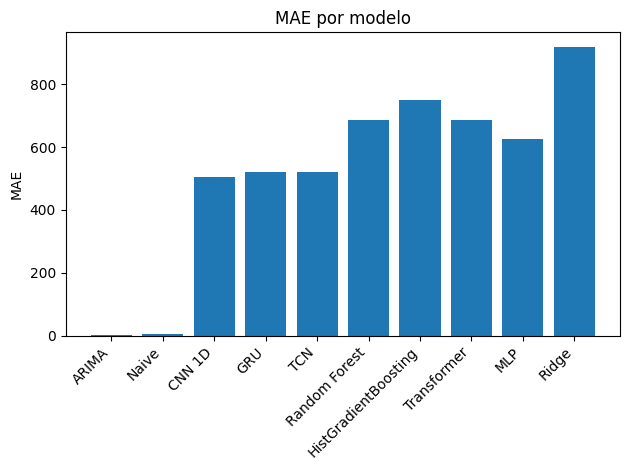

In [ ]:
plt.figure()
plt.bar(df_results["Modelo"], df_results["MAE"])
plt.title("MAE por modelo")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 8.2.2 RMSE

El error cuadrático medio (RMSE) penaliza con mayor severidad los errores grandes, por lo que resulta especialmente relevante en series con alta variabilidad. Nuevamente, ARIMA presenta el menor RMSE, reflejando un buen ajuste en términos de dispersión global. No obstante, el modelo CNN1D logra un RMSE significativamente menor que el resto de los modelos de aprendizaje profundo y automático, lo que evidencia una mejor capacidad para controlar errores extremos. Este comportamiento refuerza la idoneidad del CNN1D para capturar patrones temporales relevantes sin incurrir en sobreajuste.

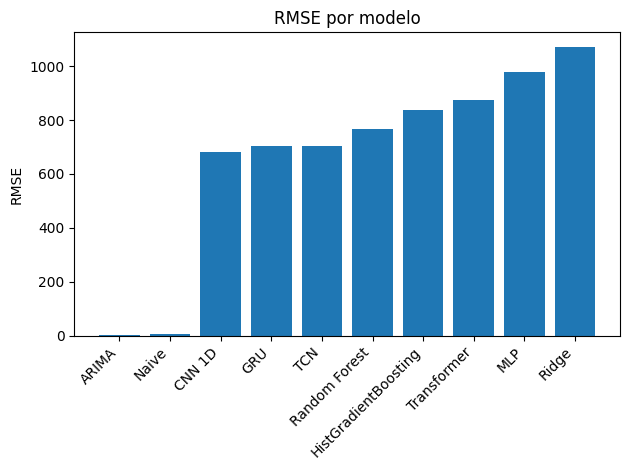

In [ ]:
plt.figure()
plt.bar(df_results["Modelo"], df_results["RMSE"])
plt.title("RMSE por modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 8.2.3 R²

El coeficiente de determinación R² evalúa la proporción de varianza explicada por el modelo. En este estudio, todos los modelos presentan valores de R² negativos, lo cual es esperable al trabajar con una serie diferenciada como ΔM2, caracterizada por alta volatilidad y choques de corto plazo. A pesar de ello, el modelo CNN1D alcanza el valor de R² menos negativo, indicando una mayor capacidad relativa para explicar la variabilidad de la serie en comparación con los demás enfoques. Este resultado sugiere que los modelos secuenciales profundos capturan mejor la estructura temporal subyacente.

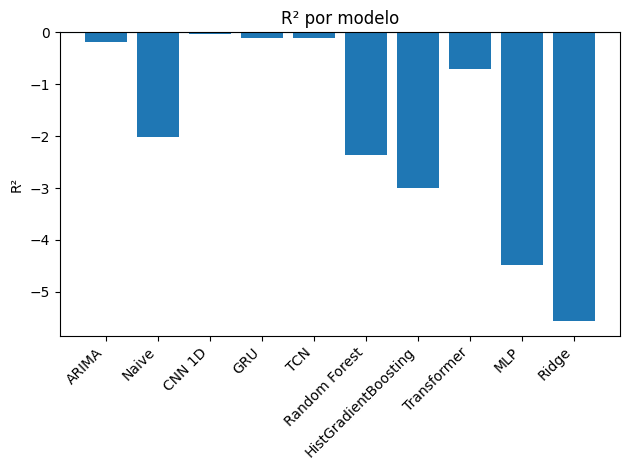

In [ ]:
plt.figure()
plt.bar(df_results["Modelo"], df_results["R2"])
plt.title("R² por modelo")
plt.ylabel("R²")
plt.axhline(0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 8.2.4 Precisión direccional

La precisión direccional mide la capacidad del modelo para anticipar correctamente el signo de la variación de M2. En este aspecto, los modelos de aprendizaje profundo, en particular CNN1D, GRU y TCN, muestran desempeños superiores, con valores de precisión direccional cercanos o superiores al 80%. En contraste, el modelo ARIMA presenta una precisión direccional muy baja, lo que limita su utilidad para análisis prospectivos. El buen desempeño del CNN1D en esta métrica refuerza su ventaja práctica, ya que permite identificar correctamente períodos de expansión o contracción monetaria.

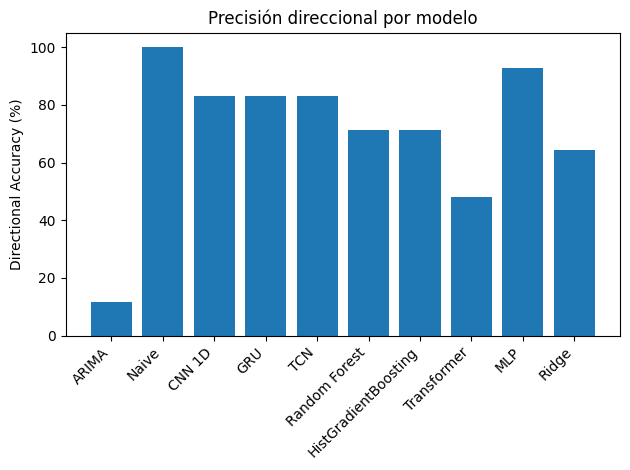

In [ ]:
plt.figure()
plt.bar(df_results["Modelo"], df_results["DirAcc"])
plt.title("Precisión direccional por modelo")
plt.ylabel("Directional Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 9.0 Explicabilidad

En este contexto, el análisis de sensibilidad mediante ablation constituye un enfoque más apropiado para interpretar el comportamiento interno del modelo. Este método evalúa cómo varía el error de predicción cuando se elimina de forma controlada una parte específica de la información de entrada, permitiendo observar directamente el impacto de cada componente sobre el desempeño del modelo. Al no introducir supuestos adicionales ni aproximaciones locales, este enfoque proporciona interpretaciones más estables y coherentes con la arquitectura del CNN1D.

Desde el punto de vista temporal, la eliminación de pasos específicos dentro de la ventana permite identificar qué rezagos aportan mayor información al proceso de predicción. Este análisis es especialmente relevante para la variación de M2 (ΔM2), una variable caracterizada por dinámicas de corto plazo, ya que permite verificar si el modelo efectivamente otorga mayor peso a la información más reciente, en concordancia con la teoría económica.

Desde el punto de vista de las variables explicativas, la desactivación individual de cada variable a lo largo de toda la ventana temporal permite cuantificar su contribución relativa al desempeño del modelo. Las variables cuya eliminación genera un mayor incremento del error se consideran más influyentes, lo que facilita una interpretación económica directa y evita explicaciones ambiguas o contradictorias.

### 9.0.1 Análisis de sensibilidad

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# EXPLICABILIDAD CNN1D (Análisis de sensibilidad / ablation)
# Requiere:
# - cnn     : modelo entrenado (Keras)
# - Xte_w   : test en ventanas (n_samples, lookback, n_vars)
# - yte_w   : target test alineado con Xte_w (n_samples,)
# - seq_feats: lista de nombres de variables (len = n_vars)
# ============================================================

def _rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def _mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

# -------------------------
# 0) Métricas base
# -------------------------
pred_base = cnn.predict(Xte_w, verbose=0).reshape(-1)
rmse_base = _rmse(yte_w, pred_base)
mae_base  = _mae(yte_w, pred_base)

print("Baseline CNN1D")
print("RMSE:", rmse_base)
print("MAE :", mae_base)

# -------------------------
# 1) Importancia temporal (por paso del lookback)
#    Se apaga un paso temporal completo (todas las variables) y se mide cuánto sube el error.
# -------------------------
temporal_imp = []
lookback = Xte_w.shape[1]

for t in range(lookback):
    X_tmp = Xte_w.copy()
    X_tmp[:, t, :] = 0.0  # apaga el paso t

    pred_t = cnn.predict(X_tmp, verbose=0).reshape(-1)
    rmse_t = _rmse(yte_w, pred_t)

    temporal_imp.append({"Paso": t+1, "Delta_RMSE": rmse_t - rmse_base})

df_temporal_imp = pd.DataFrame(temporal_imp).sort_values("Delta_RMSE", ascending=False).reset_index(drop=True)
df_temporal_imp

# -------------------------
# 2) Importancia por variable (en toda la ventana)
#    Se apaga una variable (en todos los pasos temporales) y se mide cuánto sube el error.
# -------------------------
var_imp = []
n_vars = Xte_w.shape[2]

for j in range(n_vars):
    X_tmp = Xte_w.copy()
    X_tmp[:, :, j] = 0.0  # apaga variable j en toda la ventana

    pred_j = cnn.predict(X_tmp, verbose=0).reshape(-1)
    rmse_j = _rmse(yte_w, pred_j)

    var_name = seq_feats[j] if j < len(seq_feats) else f"Var_{j}"
    var_imp.append({"Variable": var_name, "Delta_RMSE": rmse_j - rmse_base})

df_var_imp = pd.DataFrame(var_imp).sort_values("Delta_RMSE", ascending=False).reset_index(drop=True)
df_var_imp

Baseline CNN1D
RMSE: 680.3019090815488
MAE : 503.47503662109375


,Variable,Delta_RMSE
0,Base Monetaria,29.791043
1,Reservas Bancarias,23.059551
2,Caja BCE,19.832520
3,Especies Monetarias en Circulación,17.811128
4,Moneda Fraccionaria,15.510768
5,Otros,8.634363
6,Inflación Acumulada,-1.179751


**9.0.1.1 Interpretación**

muestra qué tan sensible es el modelo a cada variable: un Delta_RMSE positivo significa que al “apagar” esa variable el RMSE aumenta, por lo que esa variable sí aporta información útil; mientras más grande sea el Delta_RMSE, más importante es esa variable para el modelo.

Según tus resultados, la variable más influyente es Base Monetaria (ΔRMSE ≈ +29.79), lo que sugiere que el CNN1D depende fuertemente de la dinámica de la base para anticipar cambios en M2, algo coherente porque la base monetaria está directamente relacionada con la liquidez y el comportamiento de agregados monetarios. En segundo lugar aparecen Reservas Bancarias (≈ +23.06) y Caja BCE (≈ +19.83), indicando que el modelo está captando la relación entre la disponibilidad/posición de liquidez del sistema y la variación de M2, lo cual también es consistente con la lógica monetaria (movimientos en reservas y caja pueden acompañar expansión o absorción de dinero). Luego se ubican Especies Monetarias en Circulación (≈ +17.81) y Moneda Fraccionaria (≈ +15.51), lo que sugiere que el componente de efectivo y su composición también contribuyen de forma relevante a explicar los cambios de M2. La variable Otros aporta, pero con menor peso (≈ +8.63), lo que suele ocurrir cuando agrupa componentes heterogéneos con señales mezcladas.

El caso de Inflación Acumulada es particular porque presenta un Delta_RMSE negativo (≈ −1.18), lo que significa que al eliminarla el RMSE baja ligeramente; esto sugiere que, en este modelo y con estos datos, la inflación acumulada no está aportando señal útil para predecir ΔM2 y podría estar introduciendo ruido o relaciones inestables en el corto plazo. En términos prácticos y defendibles, este resultado justifica dos decisiones: mantenerla como variable “de control” solo si aporta en otros modelos/experimentos, o directamente excluirla del CNN1D para simplificar y potencialmente mejorar un poco el desempeño.

En conjunto, la interpretabilidad por sensibilidad respalda que el CNN1D está basando su predicción principalmente en variables monetarias estructurales (base monetaria, reservas, caja y efectivo), lo cual refuerza la coherencia económica del modelo ganador y ayuda a explicar por qué supera a alternativas más complejas: está explotando señales temporales claras de liquidez y dinámica monetaria, mientras que variables macro como inflación acumulada no contribuyen de manera consistente en este horizonte.

### 9.0.2 Importancia temporal

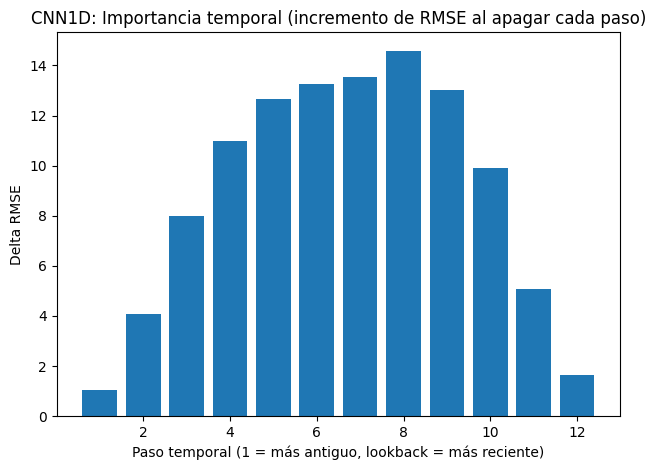

In [ ]:
# --- Importancia temporal ---
plt.figure()
plt.bar(df_temporal_imp["Paso"], df_temporal_imp["Delta_RMSE"])
plt.title("CNN1D: Importancia temporal (incremento de RMSE al apagar cada paso)")
plt.xlabel("Paso temporal (1 = más antiguo, lookback = más reciente)")
plt.ylabel("Delta RMSE")
plt.tight_layout()
plt.show()

**9.0.2.1 Interpretación**

Se observa un patrón claramente no uniforme. Los pasos intermedios–recientes concentran la mayor importancia: el máximo impacto se produce alrededor del paso 8, seguido de los pasos 6, 7 y 9. Esto indica que el modelo depende principalmente de la información contenida en ese tramo de la ventana, donde se capturan cambios recientes pero ya “asentados” en la dinámica monetaria. En términos económicos, sugiere que los efectos sobre ΔM2 no son instantáneos, sino que se materializan con un rezago corto.

Los pasos más antiguos (1–2) presentan un impacto bajo, lo que implica que la información demasiado lejana en el tiempo aporta poca señal predictiva. Del mismo modo, los pasos más recientes (11–12) muestran una importancia decreciente, lo que sugiere que el ruido de muy corto plazo no es tan informativo como el comportamiento observado algunos períodos antes.

En conjunto, el patrón es unimodal, con mayor peso en la parte media de la ventana, lo cual respalda que el CNN1D está aprendiendo dependencias temporales locales y rezagos económicamente plausibles, en lugar de memorizar valores extremos o ruido inmediato. Esta evidencia refuerza la coherencia del modelo: la predicción de ΔM2 se apoya principalmente en información reciente con un pequeño desfase temporal, consistente con la dinámica de transmisión monetaria.

### 9.0.3 Importancia por variable

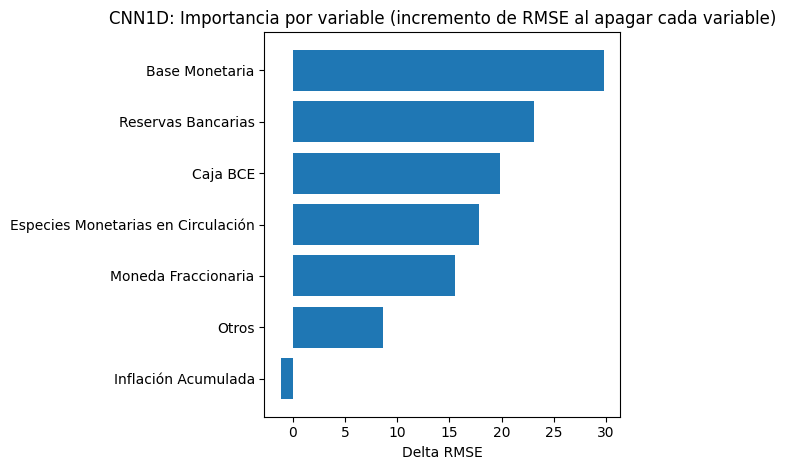

In [ ]:

# --- Importancia por variable ---
plt.figure()
plt.barh(df_var_imp["Variable"], df_var_imp["Delta_RMSE"])
plt.title("CNN1D: Importancia por variable (incremento de RMSE al apagar cada variable)")
plt.xlabel("Delta RMSE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**9.0.3.1 Interpretación**

Se observa que Base Monetaria es la variable más influyente, ya que su eliminación produce el mayor aumento del error. Esto sugiere que el CNN1D se apoya de forma central en la dinámica de la base monetaria para anticipar variaciones en M2, lo cual es coherente con la teoría monetaria al tratarse de un componente fundamental de la liquidez.

En segundo y tercer lugar aparecen Reservas Bancarias y Caja BCE, indicando que la posición de liquidez del sistema financiero y del banco central juega un papel clave en la explicación de los cambios de M2. La relevancia de estas variables refuerza la interpretación económica del modelo, al reflejar mecanismos de provisión y absorción de liquidez.

Las variables Especies Monetarias en Circulación y Moneda Fraccionaria presentan una importancia intermedia, lo que indica que los componentes de efectivo contribuyen a la predicción, aunque en menor medida que los agregados monetarios y de reservas. La categoría Otros muestra un impacto reducido, consistente con su carácter agregado y heterogéneo.

Finalmente, Inflación Acumulada presenta una contribución prácticamente nula e incluso ligeramente negativa, lo que indica que su eliminación no deteriora el desempeño del modelo. Este resultado sugiere que, en el horizonte temporal analizado y para la predicción de ΔM2, la inflación acumulada no aporta información relevante y puede introducir ruido.

En conjunto, el análisis confirma que el CNN1D basa su capacidad predictiva principalmente en variables monetarias estructurales y de liquidez, mientras que variables macroeconómicas más agregadas, como la inflación acumulada, tienen un rol marginal. Esta evidencia respalda la coherencia económica del modelo y refuerza su interpretabilidad.

In [ ]:
import pandas as pd

model_hyperparams = {
    "ARIMA": {
        "order": "(1,0,1)"
    },
    "KMeans (Clustering)": {
        "n_clusters": "2",
        "random_state": "42",
        "n_init": "20"
    },
    "Isolation Forest": {
        "n_estimators": "300",
        "contamination": "0.10",
        "random_state": "42"
    },
    "Ridge": {
        "alpha": "3.0",
        "random_state": "42"
    },
    "Random Forest": {
        "n_estimators": "400",
        "max_depth": "8",
        "min_samples_leaf": "5",
        "min_samples_split": "10",
        "random_state": "42",
        "n_jobs": "-1"
    },
    "HistGradientBoosting": {
        "learning_rate": "0.05",
        "max_depth": "3",
        "max_leaf_nodes": "15",
        "min_samples_leaf": "10",
        "random_state": "42"
    },
    "MLP": {
        "hidden_layer_sizes": "(32,16)",
        "alpha": "1e-3",
        "learning_rate_init": "1e-3",
        "max_iter": "2000",
        "early_stopping": "True",
        "validation_fraction": "0.2",
        "n_iter_no_change": "30",
        "random_state": "42"
    },
    "GRU": {
        "GRU_units": "24",
        "GRU_dropout": "0.15",
        "Dense_units": "16",
        "Dense_activation": "relu",
        "optimizer": "Adam (1e-3)",
        "loss": "mse",
        "epochs": "400",
        "batch_size": "16",
        "validation_split": "0.2",
        "early_stopping_patience": "25",
        "lookback": "12"
    },
    "Transformer": {
        "num_heads": "2",
        "key_dim": "16",
        "attn_dropout": "0.1",
        "Dense_units": "32",
        "Dense_activation": "relu",
        "optimizer": "Adam (1e-3)",
        "loss": "mse",
        "epochs": "400",
        "batch_size": "16",
        "validation_split": "0.2",
        "early_stopping_patience": "25",
        "lookback": "12"
    },
    "CNN 1D": {
        "Conv1D_filters_1": "32",
        "Conv1D_kernel_size_1": "3",
        "Conv1D_filters_2": "16",
        "Conv1D_kernel_size_2": "3",
        "Dense_units": "16",
        "Dense_activation": "relu",
        "optimizer": "Adam (1e-3)",
        "loss": "mse",
        "epochs": "300",
        "batch_size": "16",
        "validation_split": "0.2",
        "early_stopping_patience": "20",
        "lookback": "12"
    },
    "TCN": {
        "Conv1D_filters": "32",
        "Conv1D_kernel_size": "3",
        "dilation_rates": "[1, 2, 4]",
        "padding": "causal",
        "dropout": "0.15",
        "Dense_units": "16",
        "Dense_activation": "relu",
        "optimizer": "Adam (1e-3)",
        "loss": "mse",
        "epochs": "300",
        "batch_size": "16",
        "validation_split": "0.2",
        "early_stopping_patience": "20",
        "lookback": "12"
    }
}

df_hyperparams = pd.DataFrame.from_dict(model_hyperparams, orient='index')
df_hyperparams.index.name = "Modelo"
df_hyperparams = df_hyperparams.fillna('-')


display(df_hyperparams)
